In [1]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
library(data.table)
library(ggplot2)
library(ggsci)
library(scales)
library(ggrepel)
library(MASS) # for glm.nb

In [2]:
# load all auxilary files
source("scripts/post_hoc/utils.R")

In [3]:
fancy_scientific <- function(l) {
     # turn in to character string in scientific notation
     l <- format(l, scientific = TRUE)
     # quote the part before the exponent to keep all the digits
     l <- gsub("^(.*)e", "'\\1'e", l)
     # turn the 'e+' into plotmath format
     l <- gsub("e", "%*%10^", l)
     # return this as an expression
     parse(text=l)
}

fread_vcf <- function(path){
    stopifnot(file.exists(path))
    command <- paste('zcat ', path, '| grep -v "##"')
    vcf <- fread(cmd=command, sep = '\t')
    cols <- colnames(vcf)
    final_id_col <- suppressWarnings(max(which(is.na(as.numeric(colnames(vcf))))))
    metadata <- vcf[,1:final_id_col]
    genotypes <- vcf[,(final_id_col+1):ncol(vcf)]
    return(list(metadata=metadata, genotypes=genotypes))
}

### 0.1 How many variants are classified as LoF?

In [4]:
dt <- fread("data/knockouts/alt/pp90/clinvar_alleles/ukb_eur_wes_200k_clinvar_chr1.txt.gz")

In [5]:
d <- data.table(table(dt$clinvar.CLNSIG, dt$worst_csq_by_gene_canonical.most_severe_consequence))

#head(na.omit(dt$clinvar.CLNSIG),n = 100)

In [6]:
#d[d$N > 5,]

# 1.0 Variant level analysis

In [79]:
# this aggregation is now being accomplished in a seperate script
dt1 <- fread("data/post_hoc/results/ukb_wes_union_calls_200k_variants.pp90_prefilter.txt.gz")
dt2 <- fread("data/post_hoc/results/ukb_wes_union_calls_200k_variants.pp90_postfilter.txt.gz")
stopifnot((dt1$variant_category == dt2$variant_category) & (dt1$consequence_category == dt2$consequence_category))

In [93]:
# aggregate variants for simple overview
d <- dt1
d <- d[d$variant_category != "",]
d$new_cat <- NA
d$new_cat[d$variant_category %in% c("splice_acceptor_variant", "splice_donor_variant")] <- "Essential splice"
d$new_cat[d$variant_category %in% c("synonymous_variant")] <- "Synonymous"
d$new_cat[d$variant_category %in% c("stop_gained")] <- "Nonsense"
d$new_cat[d$variant_category %in% c("3_prime_UTR_variant")] <- "3'UTR"
d$new_cat[d$variant_category %in% c("5_prime_UTR_variant")] <- "5'UTR"
d$new_cat[d$variant_category %in% c("intron_variant")] <- "Intron"
d$new_cat[d$variant_category %in% c("missense_variant")] <- "Missense"
d$new_cat[d$variant_category %in% c("frameshift_variant" )] <- "Truncating"
d <- d[!is.na(d$new_cat),]

# substract singletons from total
d$n_no_singletons <- d$n_total - d$n_singletons

# setup categories
categories <- c("Intron", "5'UTR", "3'UTR", "Synonymous", 
                "Missense", "Essential splice", "Nonsense", 
                "Truncating")

# get singletons too
d_aggr <- merge(
    aggregate(n_no_singletons ~ new_cat, data = d, FUN = sum),
    aggregate(n_singletons ~ new_cat, data = d, FUN = sum)
)

# get total 
d_aggr$n_total <- d_aggr$n_no_singletons + d_aggr$n_singletons

# prepare for plotting
d_aggr_melted <- reshape2::melt(d_aggr, id.vars = c("new_cat","n_total"), measure.vars = c("n_no_singletons","n_singletons"))
d_aggr_melted$new_cat <- factor(d_aggr_melted$new_cat, levels = categories)
d_aggr_melted$variable <- factor(d_aggr_melted$variable, levels = rev(unique(d_aggr_melted$variable)))

# get only labels for top
d_aggr_melted$value_k <- scales::label_number_si(accuracy = 0.01)(d_aggr_melted$n_total)
d_aggr_melted$value_k[d_aggr_melted$variable == "n_no_singletons"] <- NA

In [95]:
reds <- c("#B13F64", "#DD686D", "#F09D7C")
greens <- c("#669850", "#7CA98A")
blues <- c("#2266AC", "#6CB7E6")

In [96]:
# setup colors
my_colors <- c(greens[2], greens[1], greens[1], greens[1], reds[3], reds[2], reds[2], reds[1])
names(my_colors) <- categories
fill_scale <- scale_fill_manual(name = "new_cat", values = my_colors)
color_scale <- scale_color_manual(name = "new_cat", values = my_colors)

In [97]:
pretty_labels <- function(f) scales::label_number_si(accuracy = 0.1)(f)

Warning message:
"Using alpha for a discrete variable is not advised."
Warning message:
"Removed 8 rows containing missing values (`geom_text()`)."


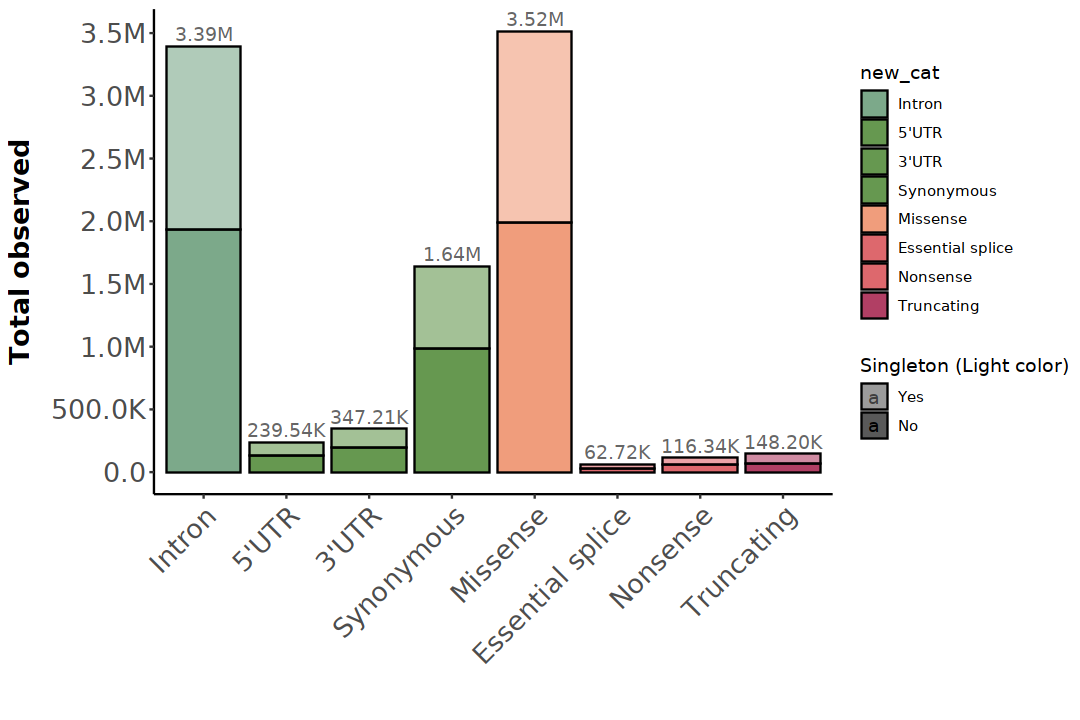

In [98]:
options(repr.plot.width=9, repr.plot.height=6)
p <- ggplot(d_aggr_melted, aes(x=new_cat, y = value, fill=new_cat, alpha = variable)) +
    geom_bar(stat='identity', color = 'black') +
    fill_scale + 
    scale_alpha_discrete(range = c(0.6, 1.0), labels = c("Yes", "No")) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10), labels=pretty_labels) +
    geom_text(aes(x=new_cat, label=value_k, y = n_total), vjust=-0.35) +
    ylab("Total observed") +
    xlab("") +
    theme_classic() + 
    labs(alpha='Singleton (Light color)') +
    theme(
        legend.position = "right",
        strip.text = element_text(size=16),
        axis.text=element_text(size=16),
        axis.title=element_text(size=16,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        axis.text.x = element_text(angle = 45, hjust = 0.99, vjust = 0.99),
        plot.title = element_text(hjust=0.5),
        panel.grid.major = element_blank(), 
        panel.grid.minor = element_blank(),
        panel.background = element_blank()
    ) 
p

In [350]:
outfile <- "derived/plots/230108_functional_variant_annotations.pdf"
ggsave(outfile, p, width = 21, height = 14, unit = "cm")

Warning message:
"Removed 8 rows containing missing values (geom_text)."


In [103]:
dt2_filter <- dt2[,c("n_total","n_singletons","pct_singletons")]
colnames(dt2_filter) <- paste0("filter_",colnames(dt2_filter))
combi <- cbind(dt1, dt2_filter) # <--- note that dt2 correspond to PP>0.9 and dt1 is PP>0

In [104]:
levels <- c("non_coding","synonymous", 'other_missense', 'damaging_missense', 'LC', 'pLoF')

In [105]:
dt_subset <- combi[combi$variant_category == "" & combi$consequence_category != "",]
dt_subset$consequence_category <- factor(as.character(dt_subset$consequence_category), levels = levels)
#dt_subset$consequence_category[1] <- "LC"
dt_subset$n_no_singletons <- dt_subset$n_total - dt_subset$n_singletons

In [106]:
# get singletons too
d_aggr <- merge(
    aggregate(n_no_singletons ~ consequence_category, data = dt_subset, FUN = sum),
    aggregate(n_singletons ~ consequence_category, data = dt_subset, FUN = sum)
)

# setup nicer category names
d_aggr$consequence_category <- gsub("_", " ", d_aggr$consequence_category)
d_aggr$n_total <- d_aggr$n_no_singletons + d_aggr$n_singletons
categories <- c('non coding','synonymous','other missense','damaging missense','pLoF')

# prepare for plotting
d_aggr_melted <- reshape2::melt(d_aggr, id.vars = c("consequence_category","n_total"), measure.vars = c("n_no_singletons","n_singletons"))
d_aggr_melted$consequence_category <- factor(d_aggr_melted$consequence_category, levels = categories)
d_aggr_melted$variable <- factor(d_aggr_melted$variable, levels = rev(unique(d_aggr_melted$variable)))

# get only labels for top
d_aggr_melted$value_k <- scales::label_number_si(accuracy = 0.01)(d_aggr_melted$n_total)
d_aggr_melted$value_k[d_aggr_melted$variable == "n_no_singletons"] <- NA

In [107]:
# setup colors
my_colors <- c(greens[2], greens[1], reds[3], reds[2], reds[1])
names(my_colors) <- categories
fill_scale <- scale_fill_manual(name = "consequence_category", values = my_colors)
color_scale <- scale_color_manual(name = "consequence_category", values = my_colors)

Warning message:
"Using alpha for a discrete variable is not advised."
Warning message:
"Removed 5 rows containing missing values (`geom_text()`)."


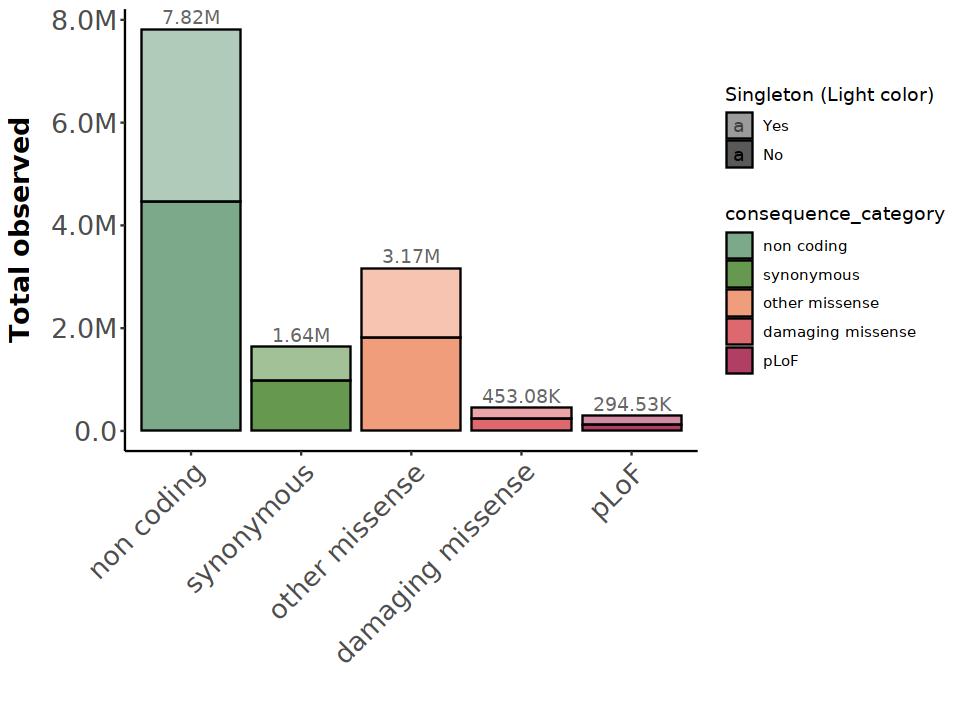

In [108]:
options(repr.plot.width=8, repr.plot.height=6)
p <- ggplot(d_aggr_melted, aes(x=consequence_category, y=value, fill=consequence_category, alpha = variable)) +
    geom_bar(stat='identity', color = 'black') +
    fill_scale + 
    scale_alpha_discrete(range = c(0.6, 1.0), labels = c("Yes", "No")) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=6), labels=pretty_labels) +
    geom_text(aes(x=consequence_category, label=value_k, y = n_total), vjust=-0.35) +
    ylab("Total observed") +
    xlab("") +
    theme_classic() + 
    labs(alpha='Singleton (Light color)') +
    theme(
        legend.position = "right",
        strip.text = element_text(size=16),
        axis.text=element_text(size=16),
        axis.title=element_text(size=16,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        axis.text.x = element_text(angle = 45, hjust = 0.99, vjust = 0.99),
        plot.title = element_text(hjust=0.5),
        panel.grid.major = element_blank(), 
        panel.grid.minor = element_blank(),
        panel.background = element_blank()
    ) 
print(p)

In [77]:
outfile <- "derived/plots/230320_functional_variant_annotations_plof_damaging_missense.pdf"
ggsave(outfile, p, width = 16, height = 14, unit = "cm")

Warning message:
"Removed 5 rows containing missing values (`geom_text()`)."


## 1.9 Variant by sample statistic

In [14]:
annotations <- c("pLoF", "pLoF_damaging_missense", "damaging_missense")

In [15]:
pLoF <- read_ukb_wes_kos("pLoF")
damaging_missense <- read_ukb_wes_kos("damaging_missense")
pLoF_damaging_missense <- read_ukb_wes_kos("pLoF_damaging_missense")

pLoF$annotation <- "pLoF"
damaging_missense$annotation <- "damaging_missense"
pLoF_damaging_missense$annotation <- "pLoF_damaging_missense"

In [16]:
#cols_to_keep <- c("gene_id","s","knockout","annotation", "pKO", "chromosome", "transcript_id", )
dt <- setDT(rbind(pLoF, damaging_missense, pLoF_damaging_missense))
dt <- dt[!(dt$knockout %in% "Heterozygote"), ]
#dt <- dt[,colnames(dt) %in% cols_to_keep, with = FALSE]

In [17]:
dt$is_chet <- dt$knockout %in% "Compound heterozygote"
dt$is_cis <- dt$knockout %in% "Compound heterozygote (cis)"
dt$is_hom <- dt$knockout %in% "Homozygote"
dt$is_ko <- dt$is_hom | dt$is_chet
dt$knockout <- NULL
dt$annotation <- factor(dt$annotation, levels = annotations)

In [18]:
counts <- data.table(table(dt$is_ko, dt$gene_id))
counts <- counts[counts$V1 == TRUE,]
counts <- counts[rev(order(counts$N))]
gene_id_exclude <- counts$V2[counts$N > 10000]
dt <- dt[!(dt$gene_id %in% gene_id_exclude),]

In [19]:
full <- dt[dt$annotation == "damaging_missense"]

# 2.0 Knockout level

## 2.0.1 How many knockouts by downsampling

In [10]:
dt <- fread("data/knockouts/tables/combined_annotations_by_sample.nohets.txt.gz")

In [6]:
lun <- function(x) length(unique(x))

downsample_knockout_count <- function(eids, n_samples, dt){
    sampled_eids <- sample(eids, size = n_samples, replace = FALSE)
    dt_sampled <- dt[dt$s %in% sampled_eids,]
    genes_chet <- dt_sampled[dt_sampled$is_chet, ]
    genes_hom <- dt_sampled[dt_sampled$is_hom, ]
    genes_both <- dt_sampled[dt_sampled$is_ko, ]
    # subset chet genes
    genes_both_plof <- genes_both[genes_both$annotation == "pLoF",]
    genes_both_plof_dammis <- genes_both[genes_both$annotation == "pLoF_damaging_missense",]
    genes_both_dammis <- genes_both[genes_both$annotation == "damaging_missense",]
    # subset chet genes
    genes_chet_plof <- genes_chet[genes_chet$annotation == "pLoF",]
    genes_chet_plof_dammis <- genes_chet[genes_chet$annotation == "pLoF_damaging_missense",]
    genes_chet_dammis <- genes_chet[genes_chet$annotation == "damaging_missense",]
    # subset hom genes
    genes_hom_plof <- genes_hom[genes_hom$annotation == "pLoF",]
    genes_hom_plof_dammis <- genes_hom[genes_hom$annotation == "pLoF_damaging_missense",]
    genes_hom_dammis <- genes_hom[genes_hom$annotation == "damaging_missense",]
    # legnth of uniquely affected CHET/HOM genes
    lun_genes_both_plof <- lun(genes_both_plof$ensembl_gene_id)
    lun_genes_both_plof_dammis <- lun(genes_both_plof_dammis$ensembl_gene_id)
    lun_genes_both_dammis <- lun(genes_both_dammis$ensembl_gene_id)
    # legnth of uniquely affected CHET genes
    lun_genes_chet_plof <- lun(genes_chet_plof$ensembl_gene_id)
    lun_genes_chet_plof_dammis <- lun(genes_chet_plof_dammis$ensembl_gene_id)
    lun_genes_chet_dammis <- lun(genes_chet_dammis$ensembl_gene_id)
    # length of unique affected hom genes
    lun_genes_hom_plof <- lun(genes_hom_plof$ensembl_gene_id)
    lun_genes_hom_plof_dammis <- lun(genes_hom_plof_dammis$ensembl_gene_id)
    lun_genes_hom_dammis <- lun(genes_hom_dammis$ensembl_gene_id)
    
    data.table(
        n_samples,
        both_plof = lun_genes_both_plof,
        both_plof_damaging_missense = lun_genes_both_plof_dammis,
        both_damaging_missense = lun_genes_both_dammis,
        chet_plof = lun_genes_chet_plof, 
        chet_plof_damaging_missense = lun_genes_chet_plof_dammis, 
        chet_damaging_missense =  lun_genes_chet_dammis,
        hom_plof = lun_genes_hom_plof, 
        hom_plof_damaging_missense = lun_genes_hom_plof_dammis, 
        hom_damaging_missense = lun_genes_hom_dammis
        )
}


downsample_knockout_count(eids, 1000, dt)

ERROR: Error in sample(eids, size = n_samples, replace = FALSE): object 'eids' not found


In [7]:
#eids <- unique(dt$s)
#do.call(rbind, replicate(10, list(downsample_knockout_count(eids, 1000, dt))))

In [8]:
downsample_iter <- function(dt, n_sample_iter, reps=100){
    eids <- unique(dt$s)
    out <- do.call(rbind, lapply(n_sample_iter, function(samples){
        do.call(rbind, replicate(reps, list(downsample_knockout_count(eids, samples, dt))))
    }))
    return(out)
}

In [24]:
#sample_iter <- c(1000, 5000, 10000, 20000, 30000, 4000, 50000, 60000, 75000, 85000, 100000, 125000, 150000, 175000)
sample_iter <- seq(1000, 175000, by = 5000)
ds <- downsample_iter(dt, sample_iter, reps = 100)

In [25]:
sample_categories <- unique(ds$n_samples)
counts <- do.call(rbind, lapply(sample_categories, function(cat){
    ds_subset <- ds[ds$n_samples == cat,]
    cis <- t(apply(ds_subset[,-1], 2, function(x) quantile(x, probs = c(0.025, 0.50, 0.975))))
    names <- rownames(cis)
    values <- data.table(cis)
    colnames(values) <- c("lower","est","upper")
    cis <- cbind(names, values)
    cis$n_samples <- cat
    return(cis)
}))

In [26]:
counts$names <- gsub("plof","pLoF", counts$names)
counts$category <- gsub("_","",stringr::str_extract(counts$names, "[a-z]+_"))
counts$annotation <- gsub("((both)|(chet)|(hom))\\_", "", counts$names)

In [27]:
annotations <- c("pLoF", "pLoF_damaging_missense", "damaging_missense")
categories <- annotations
my_colors <- c("#B13F64","#DD686D", "#F09D7C")
names(my_colors) <- categories
fill_scale <- scale_fill_manual(name = "annotation", values = my_colors)
color_scale <- scale_color_manual(name = "annotation", values = my_colors)

In [28]:
my_shapes <- c(19, 15) #c(21, 22)
names(my_shapes) <- c("both", "hom")
shape_scale <- scale_shape_manual(name = "category", values = my_shapes)
linetype_scale <- scale_linetype_manual(name = "category", values = c("solid","longdash"))

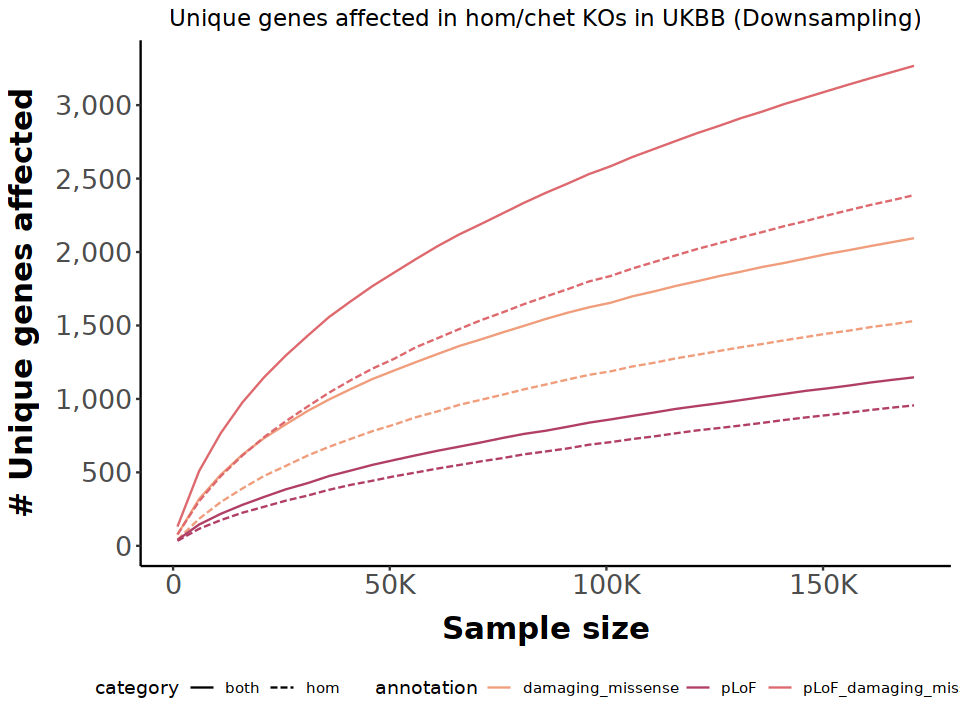

In [37]:
options(repr.plot.width=8, repr.plot.height=6)
counts_df <- counts[counts$category %in% c("both","hom"),]
p <- ggplot(counts_df, 
       aes(
           x=n_samples, y=est, ymin=lower, ymax=upper, color=annotation, 
           linetype=category, shape=category)) +
    #geom_pointrange() +
    #geom_point(size = 2.5) +    
    geom_line() + 
    scale_x_continuous(breaks=c(0, 50, 100, 150, 200)*1000, labels = scales::label_number_si()) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10), labels = scales::comma) +
    ylab("# Unique genes affected") +
    xlab("Sample size") + 
    color_scale +
    #shape_scale + 
    linetype_scale +
    theme_classic() +
    theme(
        legend.position = "bottom",
        strip.text = element_text(size=18),
        axis.text=element_text(size=16),
        axis.title=element_text(size=18,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
    ) +
    ggtitle("Unique genes affected in hom/chet KOs in UKBB (Downsampling)")
p

In [39]:
ggsave("derived/plots/230201_kos_per_sample_size_downsampled.pdf", p, width = 8, height = 6)

## 2.0 How many knockouts per category (including non-coding/other):

In [4]:
dt <- fread("data/knockouts/tables/combined_annotations_by_sample.nohets.txt.gz")
#dt_subset <- dt[dt$annotation == "pLoF_damaging_missense", ]
dt_subset <- dt
aggr_chet <- aggregate(is_chet ~ ensembl_gene_id + ensembl_transcript_id + annotation, data = dt_subset, FUN=sum)
aggr_cis <- aggregate(is_cis ~ ensembl_gene_id + ensembl_transcript_id + annotation, data = dt_subset, FUN=sum)
aggr_hom <- aggregate(is_hom ~ ensembl_gene_id + ensembl_transcript_id + annotation, data = dt_subset, FUN=sum)
aggr_ko <- aggregate(is_ko ~ ensembl_gene_id + ensembl_transcript_id, data = dt_subset, FUN=sum)
aggr <- merge(aggr_chet, aggr_hom, all = TRUE)
aggr <- merge(aggr, aggr_cis, all = TRUE)
aggr <- merge(aggr, aggr_ko, all = TRUE)

In [221]:
#aggr[(aggr$is_chet >= 2) | (aggr$is_hom >= 2),]

## 2.1. How many knockouts per category?

In [5]:
annotations <- c("pLoF", "pLoF_damaging_missense", "damaging_missense")

In [6]:
pLoF <- read_ukb_wes_kos("pLoF")
damaging_missense <- read_ukb_wes_kos("damaging_missense")
pLoF_damaging_missense <- read_ukb_wes_kos("pLoF_damaging_missense")

In [7]:
pLoF$annotation <- "pLoF"
damaging_missense$annotation <- "damaging_missense"
pLoF_damaging_missense$annotation <- "pLoF_damaging_missense"

In [8]:
cols_to_keep <- c("gene_id","s","knockout","annotation", "pKO", "chromosome", "transcript_id")
dt <- setDT(rbind(pLoF, damaging_missense, pLoF_damaging_missense))
dt <- dt[!(dt$knockout %in% "Heterozygote"), ]
dt <- dt[,colnames(dt) %in% cols_to_keep, with = FALSE]

In [9]:
dt$is_chet <- dt$knockout %in% "Compound heterozygote"
dt$is_cis <- dt$knockout %in% "Compound heterozygote (cis)"
dt$is_hom <- dt$knockout %in% "Homozygote"
dt$is_ko <- dt$is_hom | dt$is_chet
dt$knockout <- NULL
dt$annotation <- factor(dt$annotation, levels = annotations)

In [10]:
counts <- data.table(table(dt$is_ko, dt$gene_id))
counts <- counts[counts$V1 == TRUE,]
counts <- counts[rev(order(counts$N))]
gene_id_exclude <- counts$V2[counts$N > 10000]
dt <- dt[!(dt$gene_id %in% gene_id_exclude),]

In [11]:
# melt accordingly
melted <- melt(dt, measure.vars = c("is_chet","is_hom","is_cis"))
aggr <- aggregate(value~variable+annotation, data = melted, FUN = sum)
aggr$annotation <- factor(aggr$annotation, levels = annotations)

In [12]:
categories <- annotations
my_colors <- c("#B13F64","#DD686D", "#F09D7C")
names(my_colors) <- categories
fill_scale <- scale_fill_manual(name = "consequence_category", values = my_colors)
color_scale <- scale_color_manual(name = "consequence_category", values = my_colors)

In [13]:
newnames <- c(
    "is_chet" = "Compound  \nheterozygote",
    "is_hom" = "Homozygote",
    "is_cis" = "Two-hit (cis)"
)
aggr$label <- newnames[aggr$variable]
aggr$value_k <- scales::label_number_si(accuracy = 0.1)(aggr$value)

Warning message:
"`label_number_si()` was deprecated in scales 1.2.0.
i Please use the `scale_cut` argument of `label_number()` instead."


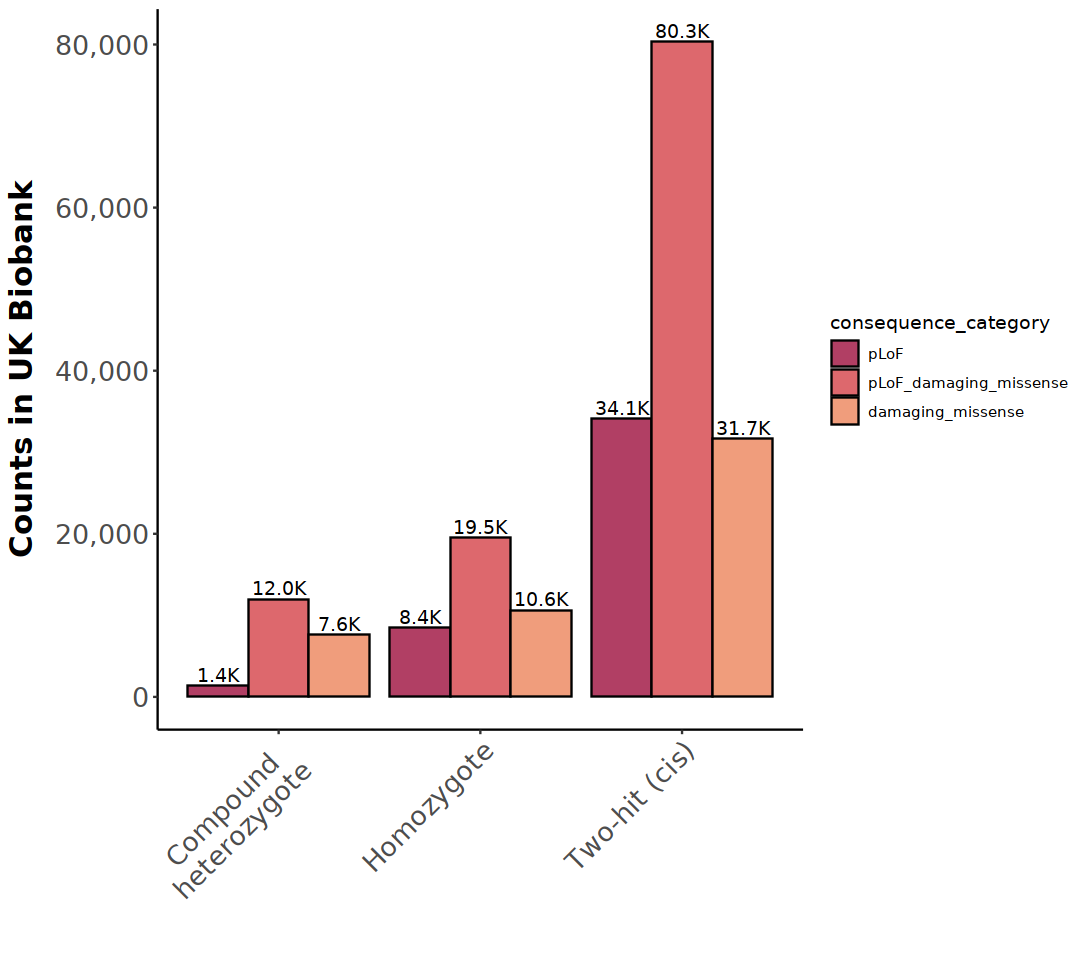

In [14]:
options(repr.plot.width=9, repr.plot.height=8)
pd <- position_dodge()
p <- ggplot(aggr, aes(x=label, y=value, fill = annotation, group=annotation)) +
    geom_bar(stat='identity', position="dodge", color = 'black') +
    theme_classic() +
    scale_y_continuous(
        breaks=scales::pretty_breaks(n=5), 
        labels = scales::comma
    ) +
    ylab("Counts in UK Biobank") +
    xlab("") +
    fill_scale +
    theme_classic() +
    geom_text(aes(x=label, label=value_k), position=position_dodge(width=0.9), vjust=-0.28) +
    theme(
        legend.position = "right",
        strip.text = element_text(size=18),
        axis.text=element_text(size=16),
        axis.title=element_text(size=18,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        axis.text.x = element_text(angle = 45, hjust = 0.99, vjust = 0.99),
        plot.title = element_text(hjust=0.5),
        panel.grid.major = element_blank(), 
        panel.grid.minor = element_blank(),
        panel.background = element_blank()
    ) 
p

In [15]:
out_prefix <- "derived/plots/220103_ko_count_ukbb_by_consequence_and_type"
#ggsave(paste0(out_prefix, ".pdf"), p, width = 10, height = 7)
#fwrite(aggr, paste0(out_prefix, ".txt"))


## 2.2 Number of knockouts per gene

In [4]:
annotations <- c("pLoF", "pLoF_damaging_missense", "damaging_missense")

In [5]:
# retrive them
pLoF <- read_ukb_wes_kos("pLoF")
damaging_missense <- read_ukb_wes_kos("damaging_missense")
pLoF_damaging_missense <- read_ukb_wes_kos("pLoF_damaging_missense")

# annotate
pLoF$annotation <- "pLoF"
damaging_missense$annotation <- "damaging_missense"
pLoF_damaging_missense$annotation <- "pLoF_damaging_missense"

In [6]:
# keep only relevant columns
cols_to_keep <- c("gene_id","s","knockout","annotation", "pKO", "chromosome", "transcript_id")
dt <- setDT(rbind(pLoF, damaging_missense, pLoF_damaging_missense))
dt <- dt[!(dt$knockout %in% "Heterozygote"), ]
dt <- dt[,colnames(dt) %in% cols_to_keep, with = FALSE]

# format
dt$is_chet <- dt$knockout %in% "Compound heterozygote"
dt$is_cis <- dt$knockout %in% "Compound heterozygote (cis)"
dt$is_hom <- dt$knockout %in% "Homozygote"
dt$is_ko <- dt$is_hom | dt$is_chet
dt$knockout <- NULL

# exclude common knockoiuts
counts <- data.table(table(dt$is_ko, dt$gene_id))
counts <- counts[counts$V1 == TRUE,]
counts <- counts[rev(order(counts$N))]
gene_id_exclude <- counts$V2[counts$N > 10000]
dt <- dt[!(dt$gene_id %in% gene_id_exclude),]

In [7]:
dt_ko_only  <- dt[dt$is_ko,]

In [8]:
# get number of genes with >= 4 knockouts
d_gene <- aggregate(is_ko ~ gene_id, data = dt[dt$annotation == "pLoF_damaging_missense",], FUN = sum)
d_gene <- d_gene[d_gene$is_ko > 0,]
to_run <- sum(d_gene$is_ko >= 4)
out_of <- sum(d_gene$is_ko >= 1)
print(paste(to_run, "of", out_of, "genes that we test."))

[1] "1143 of 3313 genes that we test."


In [9]:
x <- unlist(lapply(1:10, function(i){
    # get number of genes with >= 4 knockouts
    d_gene <- aggregate(is_ko ~ gene_id, data = dt[dt$annotation == "pLoF_damaging_missense",], FUN = sum)
    d_gene <- d_gene[d_gene$is_ko > 0,]
    to_run <- sum(d_gene$is_ko >= i)
    out_of <- sum(d_gene$is_ko >= 1)
    print(paste(to_run, "of", out_of, "genes that we test."))
    return(to_run)
}))

[1] "3313 of 3313 genes that we test."
[1] "1895 of 3313 genes that we test."
[1] "1408 of 3313 genes that we test."
[1] "1143 of 3313 genes that we test."
[1] "958 of 3313 genes that we test."
[1] "848 of 3313 genes that we test."
[1] "742 of 3313 genes that we test."
[1] "648 of 3313 genes that we test."
[1] "587 of 3313 genes that we test."
[1] "534 of 3313 genes that we test."


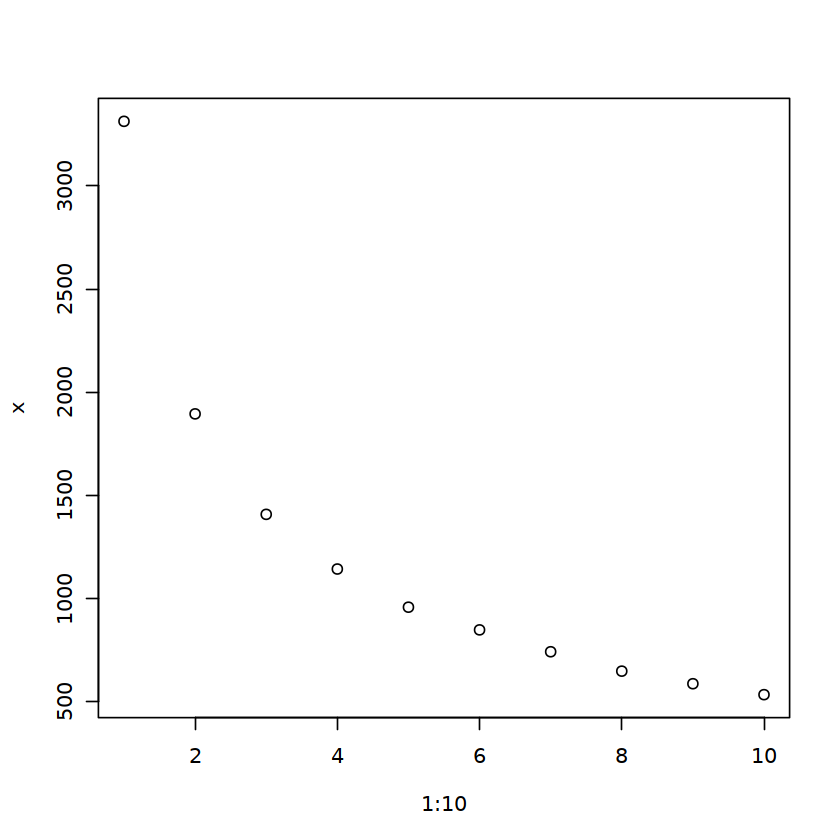

In [10]:
plot(1:10, x, lty = 1)

In [21]:
# count number of knockout carries per gene
ko_per_gene <- data.table(table(dt_ko_only$gene_id, dt_ko_only$annotation))
colnames(ko_per_gene) <- c("gene_id","annotation","N")
ko_per_gene <- ko_per_gene[ko_per_gene$N > 0,]
ko_per_gene <- data.table(table(ko_per_gene$N, ko_per_gene$annotation))
colnames(ko_per_gene) <- c("kos","annotation","N")
levels <- unique(as.character(sort(as.numeric(ko_per_gene$kos))))
ko_per_gene$kos_count <- as.numeric(ko_per_gene$kos)
ko_per_gene$kos <- factor(as.character(ko_per_gene$kos), levels = levels)

# aggregate anything above a certain threshold
kos_limit <- 10
kos_with_limit <- ko_per_gene[ko_per_gene$kos_count >= kos_limit, ]
kos_with_limit <- setDT(aggregate(N~annotation, FUN=sum, data=kos_with_limit))
kos <- paste0(kos_limit,"+")
kos_with_limit <- cbind(kos, kos_with_limit)

# clean up original and append
ko_per_gene <- ko_per_gene[ko_per_gene$kos_count < kos_limit, ]
ko_per_gene$kos_count <- NULL
combined <- rbind(ko_per_gene, kos_with_limit)
combined$annotation <- factor(combined$annotation, levels = annotations)

In [17]:
levels(combined$annotation)

[1] "pLoF"                   "pLoF_damaging_missense" "damaging_missense"

kos,annotation,N
<fct>,<fct>,<int>
1,damaging_missense,898
2,damaging_missense,326
3,damaging_missense,161
4,damaging_missense,119
5,damaging_missense,69
6,damaging_missense,77
7,damaging_missense,60
8,damaging_missense,42
9,damaging_missense,39


In [ ]:
categories <- levels(combined$annotation)
my_colors <- c("#B13F64","#DD686D", "#F09D7C")
names(my_colors) <- categories
fill_scale <- scale_fill_manual(name = "consequence_category", values = my_colors)
color_scale <- scale_color_manual(name = "consequence_category", values = my_colors)

In [ ]:
options(repr.plot.width=10, repr.plot.height=7)
p <- ggplot(combined, aes(x=kos, y=N, fill=annotation)) +
    geom_bar(stat='identity', position="dodge", color = 'black') +
    coord_cartesian(xlim = c(1,10)) +
    theme_classic() +
    scale_y_continuous(
        breaks=scales::pretty_breaks(n=10), 
        labels = scales::comma
    ) +
    fill_scale +
    xlab("Number of knockout carriers per gene") +
    ylab("Number of genes") +
    #scale_y_continuous(trans = 'log10', breaks=c(10, 500, 1000, 2000)) +    
    #annotation_logticks(sides='l')  +
    theme(
        legend.position = "bottom",
        strip.text = element_text(size=18),
        axis.text=element_text(size=16),
        axis.title=element_text(size=18,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        panel.grid.major = element_blank(), 
        panel.grid.minor = element_blank(),
        panel.background = element_blank()
    )

p

In [ ]:
com

In [40]:
out_prefix <- "derived/plots/220103_ko_carriers_per_gene_by_csqs"
ggsave(paste0(out_prefix, ".pdf"), p, width = 10, height = 7)
fwrite(aggr, paste0(out_prefix, ".txt"))

## 2.3 Compound het allele frequency distributions

In [4]:
# retrive them
pLoF <- read_ukb_wes_kos("pLoF")
damaging_missense <- read_ukb_wes_kos("damaging_missense")
pLoF_damaging_missense <- read_ukb_wes_kos("pLoF_damaging_missense")

# annotate
pLoF$annotation <- "pLoF"
damaging_missense$annotation <- "damaging_missense"
pLoF_damaging_missense$annotation <- "pLoF_damaging_missense"

In [5]:
dt <- setDT(rbind(pLoF, damaging_missense, pLoF_damaging_missense))
dt <- dt[!(dt$knockout %in% "Heterozygote"), ]

# format
dt$is_chet <- dt$knockout %in% "Compound heterozygote"
dt$is_cis <- dt$knockout %in% "Compound heterozygote (cis)"
dt$is_hom <- dt$knockout %in% "Homozygote"
dt$is_ko <- dt$is_hom | dt$is_chet
dt$knockout <- NULL

# exclude common knockoiuts
counts <- data.table(table(dt$is_ko, dt$gene_id))
counts <- counts[counts$V1 == TRUE,]
counts <- counts[rev(order(counts$N))]
gene_id_exclude <- counts$V2[counts$N > 10000]
dt <- dt[!(dt$gene_id %in% gene_id_exclude),]
dt <- dt[dt$intron == "",]

In [6]:
annotations <- c("pLoF","damaging_missense","pLoF_damaging_missense")
subsets <- list(chet=dt[dt$is_chet,], cis=dt[dt$is_cis,])

In [13]:
head(dt)

s,gene_id,transcript_id,varid,gts,AC,AF,AN,hom_alt_n,phased.a1,⋯,most_severe_consequence,revel_score,cadd_phred,exon,intron,annotation,is_chet,is_cis,is_hom,is_ko
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>
4493380,ENSG00000001461,ENST00000374399,chr1:24464071:GAAGAA:G;chr1:24464078:CCCAT:C,1|0;1|0,2;2,5.6629e-06;5.6629e-06,353174;353174,0,2,⋯,frameshift_variant;frameshift_variant,NA,,11/12;11/12,,pLoF,FALSE,TRUE,FALSE,FALSE
4659370,ENSG00000001461,ENST00000374399,chr1:24464071:GAAGAA:G;chr1:24464078:CCCAT:C,1|0;1|0,2;2,5.6629e-06;5.6629e-06,353174;353174,0,2,⋯,frameshift_variant;frameshift_variant,NA,,11/12;11/12,,pLoF,FALSE,TRUE,FALSE,FALSE
4650058,ENSG00000006555,ENST00000371276,chr1:54800699:GT:G;chr1:54800702:GCCCTGCTCGGC:G,0|1;0|1,2;2,5.6629e-06;5.6629e-06,353174;353174,0,0,⋯,frameshift_variant;frameshift_variant,NA,,1/7;1/7,,pLoF,FALSE,TRUE,FALSE,FALSE
5724094,ENSG00000006555,ENST00000371276,chr1:54800699:GT:G;chr1:54800702:GCCCTGCTCGGC:G,1|0;1|0,2;2,5.6629e-06;5.6629e-06,353174;353174,0,2,⋯,frameshift_variant;frameshift_variant,NA,,1/7;1/7,,pLoF,FALSE,TRUE,FALSE,FALSE
1509352,ENSG00000009724,ENST00000400897,chr1:11030850:T:TA;chr1:11030851:G:GGAGT,1|0;1|0,3;3,8.4944e-06;8.4944e-06,353174;353174,0,2,⋯,frameshift_variant;frameshift_variant,NA,,9/11;9/11,,pLoF,FALSE,TRUE,FALSE,FALSE
1523234,ENSG00000009724,ENST00000400897,chr1:11027169:CA:C;chr1:11027172:TCG:T,1|0;1|0,5;5,1.4157e-05;1.4157e-05,353174;353174,0,2,⋯,frameshift_variant;frameshift_variant,NA,,11/11;11/11,,pLoF,FALSE,TRUE,FALSE,FALSE


In [86]:
ac_count <- do.call(rbind,lapply(names(subsets), function(subset_name){
    dt_subset <- subsets[[subset_name]]
    inner_list <- do.call(rbind, lapply(annotations, function(anno){
        full <- dt_subset[dt_subset$annotation %in% anno,]
        ac <- do.call(rbind, lapply(1:nrow(full), function(idx){
            ac_field <- full$AC[idx]
            an_field <- full$AN[idx]
            var_field <- full$varid[idx]
            splitted_an <- as.numeric(unlist(strsplit(an_field, split = ';')))
            splitted_ac <- as.numeric(unlist(strsplit(ac_field, split = ';')))
            splitted_var <- as.numeric(gsub("\\:","",unlist(stringr::str_extract_all(var_field, pattern = ":[0-9]+:"))))
            pos1 <- splitted_var[1]
            pos2 <- splitted_var[2]
            an1 <- splitted_an[1]
            an2 <- splitted_an[2]
            ac1 <- splitted_ac[1]
            ac2 <- splitted_ac[2]
            acs <- c(ac1, ac2)
            minor_ac <- min(splitted_ac)
            major_ac <- max(splitted_ac)
            out <- data.frame(ac1, ac2, an1, an2, pos1, pos2, minor_ac, major_ac)
            out$annotation <- anno
            out$subset <- subset_name
            return(out)
        }))
        return(ac)
    }))
    return(inner_list)
}))

In [87]:
#plot(density(log10(ac_count$ac1)))
#abline(v=log10(1800), col = 'red')
#plot(density(log10(ac_count$ac2)))
#abline(v=log10(1800), col = 'red')

In [88]:
ac_count$dist <- abs(ac_count$pos1 - ac_count$pos2)

In [89]:
head(ac_count)

,ac1,ac2,an1,an2,pos1,pos2,minor_ac,major_ac,annotation,subset,dist
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
1,6,1165,353174,353174,212377629,212379901,6,1165,pLoF,chet,2272
2,1768,1797,353174,353174,13778643,13778646,1768,1797,pLoF,chet,3
3,1768,1797,353174,353174,13778643,13778646,1768,1797,pLoF,chet,3
4,11212,1,353174,353174,236543000,236543624,1,11212,pLoF,chet,624
5,11212,45,353174,353174,236543000,236543587,45,11212,pLoF,chet,587
6,11212,4,353174,353174,236543000,236543028,4,11212,pLoF,chet,28


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
"Removed 26 rows containing non-finite values (`stat_bin()`)."
Warning message:
"Transformation introduced infinite values in continuous y-axis"
Warning message:
"Removed 5 rows containing missing values (`geom_bar()`)."


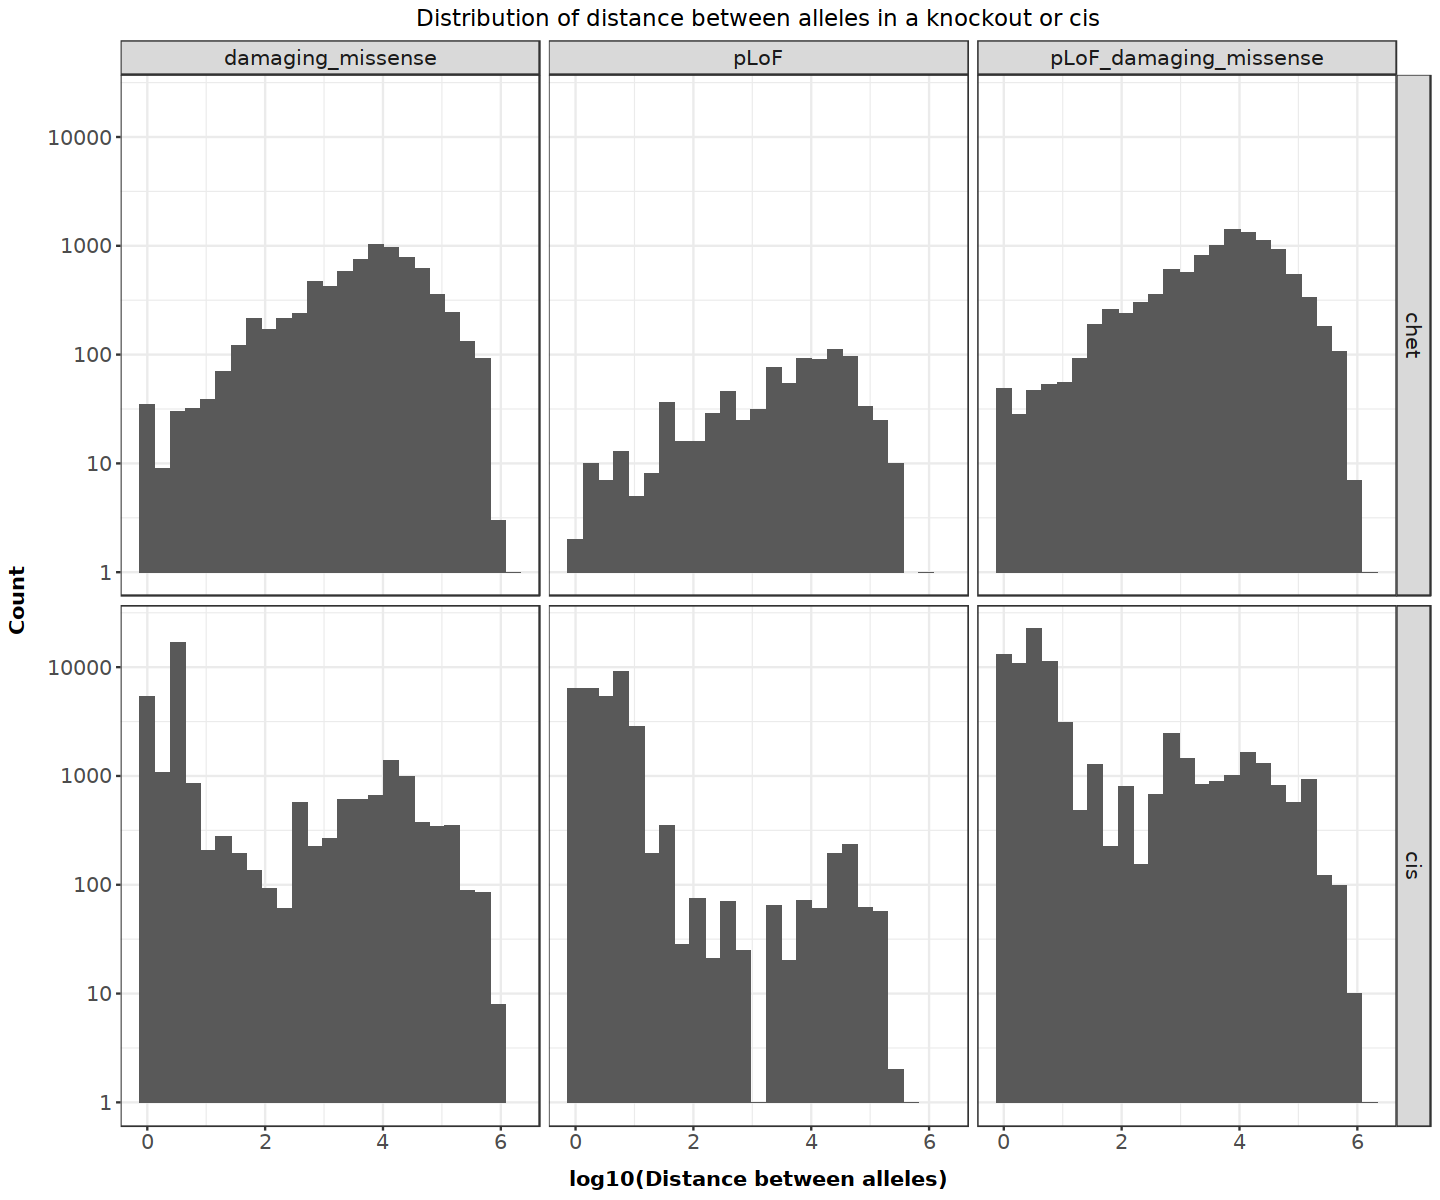

In [90]:
options(repr.plot.width=12, repr.plot.height=10)
ggplot(ac_count, aes(x=log10(dist))) +
    geom_histogram(bins = 25) +
    xlab("log10(Distance between alleles)") +
    ylab("Count") +
    ggtitle("Distribution of distance between alleles in a knockout or cis") + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_log10() +
    theme_bw() +
    theme(
        legend.position = "right",
        strip.text = element_text(size=12),
        axis.text=element_text(size=12),
        axis.title=element_text(size=12,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
    ) +
    facet_grid(subset~annotation)


In [95]:
options(repr.plot.width=14, repr.plot.height=5)
chet_count <- ac_count[ac_count$subset == "chet",]
cis_count <- ac_count[ac_count$subset == "cis",]
p1 <- ggplot(chet_count, aes(x=major_ac,y=minor_ac)) +
    geom_bin_2d(bins = 20, color = 'grey80') +
    ylab("Haplotype I MAC") +
    xlab("Haplotype II MAC") +
    ggtitle("Bi-allelic haplotype disruption") + 
    scale_fill_gradient(low = "white", high="red") +
    scale_x_continuous(trans="log10") +
    scale_y_continuous(trans="log10") +
    theme_bw() +
    theme(
        legend.position = "right",
        strip.text = element_text(size=12),
        axis.text=element_text(size=12),
        axis.title=element_text(size=12,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        #panel.border = element_blank(), 
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank()
    ) +
    facet_grid(~annotation)

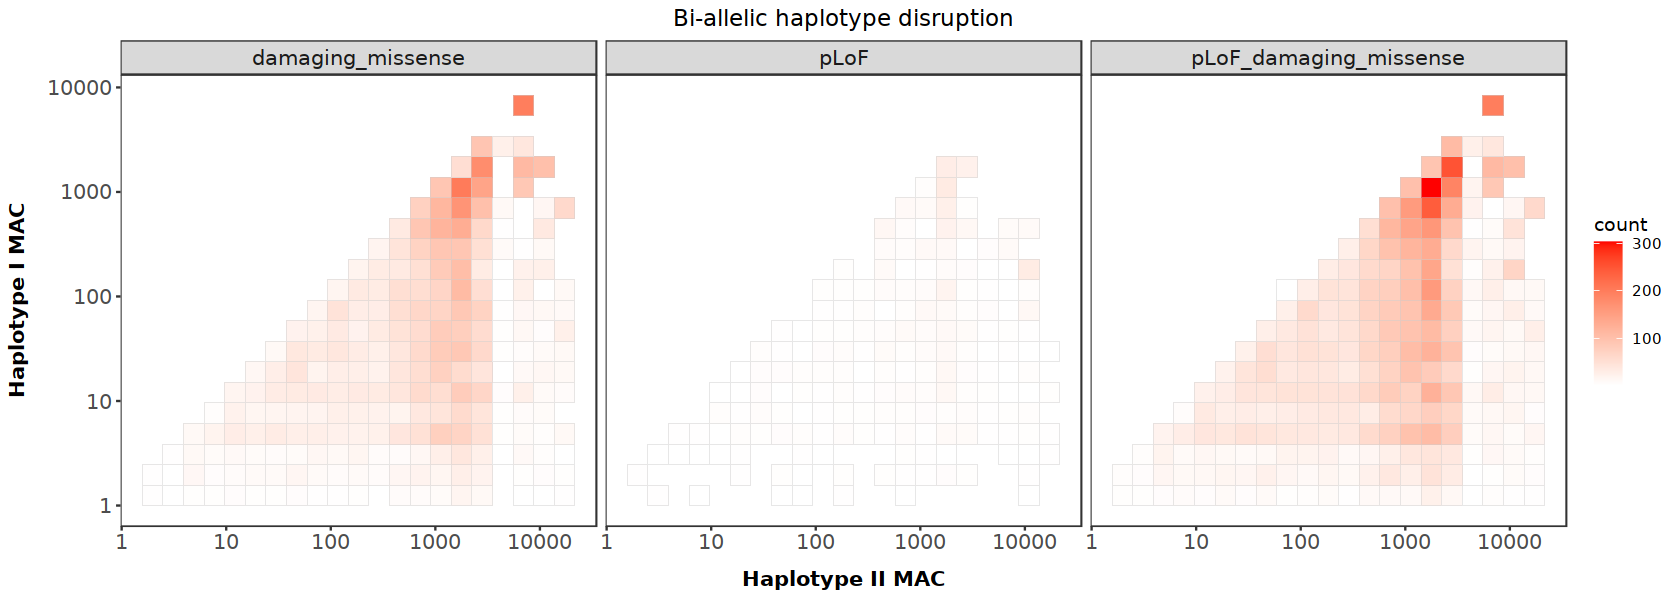

In [96]:
p1
ggsave("derived/plots/230325_bi_allelic_disruption_hm.pdf", width=12, height=5)

In [97]:
p2 <- ggplot(cis_count, aes(x=major_ac,y=minor_ac)) +
    geom_bin_2d(bins = 20, color = "grey80") +
    ylab("Haplotype I MAC ") +
    xlab("Haplotype II MAC") +
    ggtitle("Mono-allelic haplotype disruption") + 
    scale_fill_gradient(low = "white", high="blue") +
    scale_x_continuous(trans="log10") +
    scale_y_continuous(trans="log10") +
    theme_bw() +
    theme(
        legend.position = "right",
        strip.text = element_text(size=12),
        axis.text=element_text(size=12),
        axis.title=element_text(size=12,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank()
    ) +
    facet_grid(~annotation)

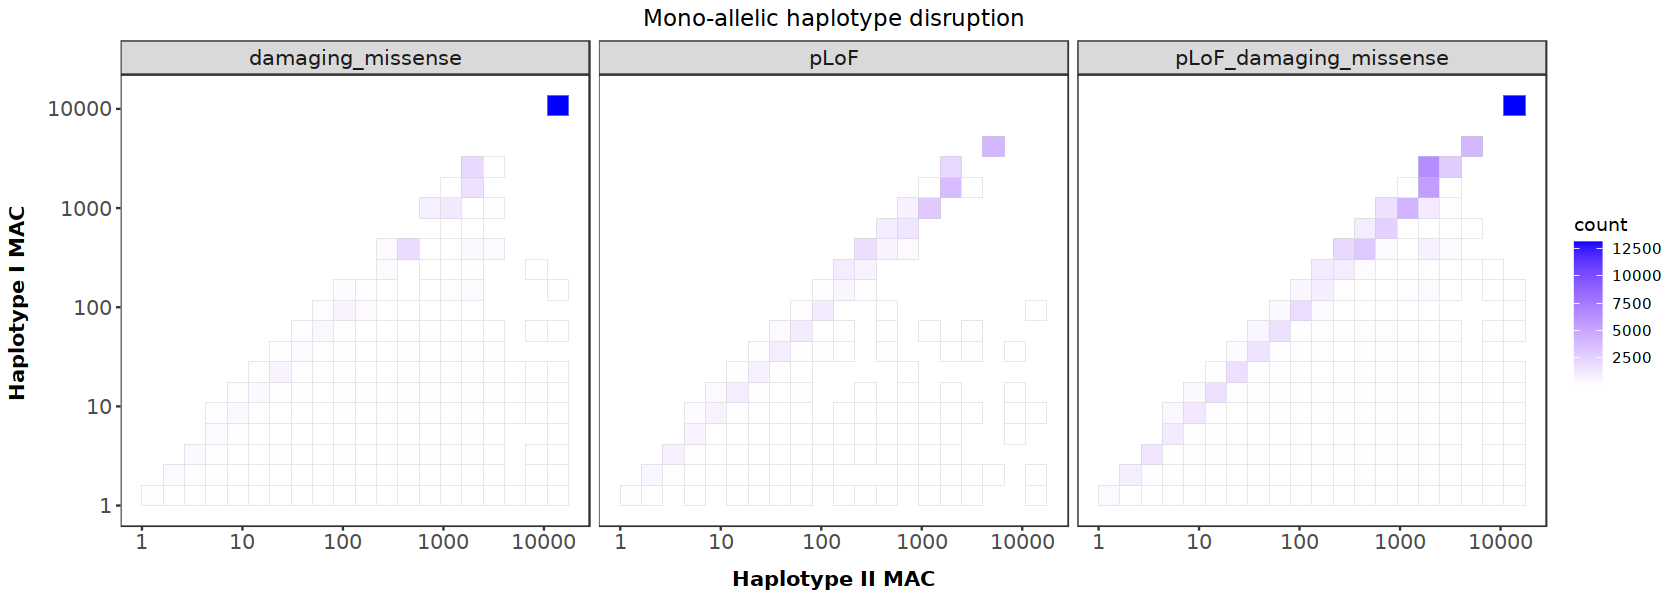

In [98]:
p2
ggsave("derived/plots/230325_mono_allelic_disruption_hm.pdf", width=12, height=5)

In [170]:
options(repr.plot.width=12, repr.plot.height=6)
ac_count$delta_ac <- abs(ac_count$major_ac - ac_count$minor_ac)
full <- ac_count

In [175]:
aggregate(delta_ac~annotation+subset, FUN=median, data=ac_count)

annotation,subset,delta_ac
<chr>,<chr>,<dbl>
damaging_missense,chet,836
pLoF,chet,927
pLoF_damaging_missense,chet,831
damaging_missense,cis,21
pLoF,cis,3
pLoF_damaging_missense,cis,8


In [176]:
pvalues <- lapply(unique(full$annotation), function(anno){
    d_subset <- full[full$annotation %in% anno,]
    d1 <- d_subset[d_subset$subset %in% "chet",]
    d2 <- d_subset[d_subset$subset %in% "cis",]
    return(t.test(d1$delta_ac, d2$delta_ac, paired = FALSE)$p.value)
})

In [179]:
# collapse
ac_count_test <- full
ac_count_test <- ac_count_test[,c("pos1","pos2","minor_ac","major_ac","annotation","subset","delta_ac")]
ac_count_test <- ac_count_test[duplicated(ac_count_test),]
aggregate(delta_ac~annotation+subset, FUN=median, data=ac_count_test)
aggregate(delta_ac~annotation+subset, FUN=mean, data=ac_count_test)

annotation,subset,delta_ac
<chr>,<chr>,<dbl>
damaging_missense,chet,1180
pLoF,chet,1382
pLoF_damaging_missense,chet,1181
damaging_missense,cis,21
pLoF,cis,4
pLoF_damaging_missense,cis,15


annotation,subset,delta_ac
<chr>,<chr>,<dbl>
damaging_missense,chet,2990.10559
pLoF,chet,3361.00820
pLoF_damaging_missense,chet,2847.22717
damaging_missense,cis,210.39064
pLoF,cis,45.77541
pLoF_damaging_missense,cis,158.63298


In [ ]:
ggplot(ac_count_test[ac_count_test$subset == "chet",], aes(x=delta_ac)) +
    geom_density() +
    scale_x_continuous(trans="log10") +
    geom_vline(data = data.table(subset=""))
    theme_bw() +
    xlab("Difference in MAC between\ndamaging alleles ") +
    facet_grid(subset~annotation)

ggplot(full[full$subset == "chet",], aes(x=delta_ac)) +
    geom_density() +
    scale_x_continuous(trans="log10") +
    theme_bw() +
    xlab("Difference in MAC between\ndamaging alleles ") +
    facet_grid(subset~annotation)

Warning message:
"Transformation introduced infinite values in continuous y-axis"
Warning message:
"Removed 40351 rows containing non-finite values (`stat_boxplot()`)."


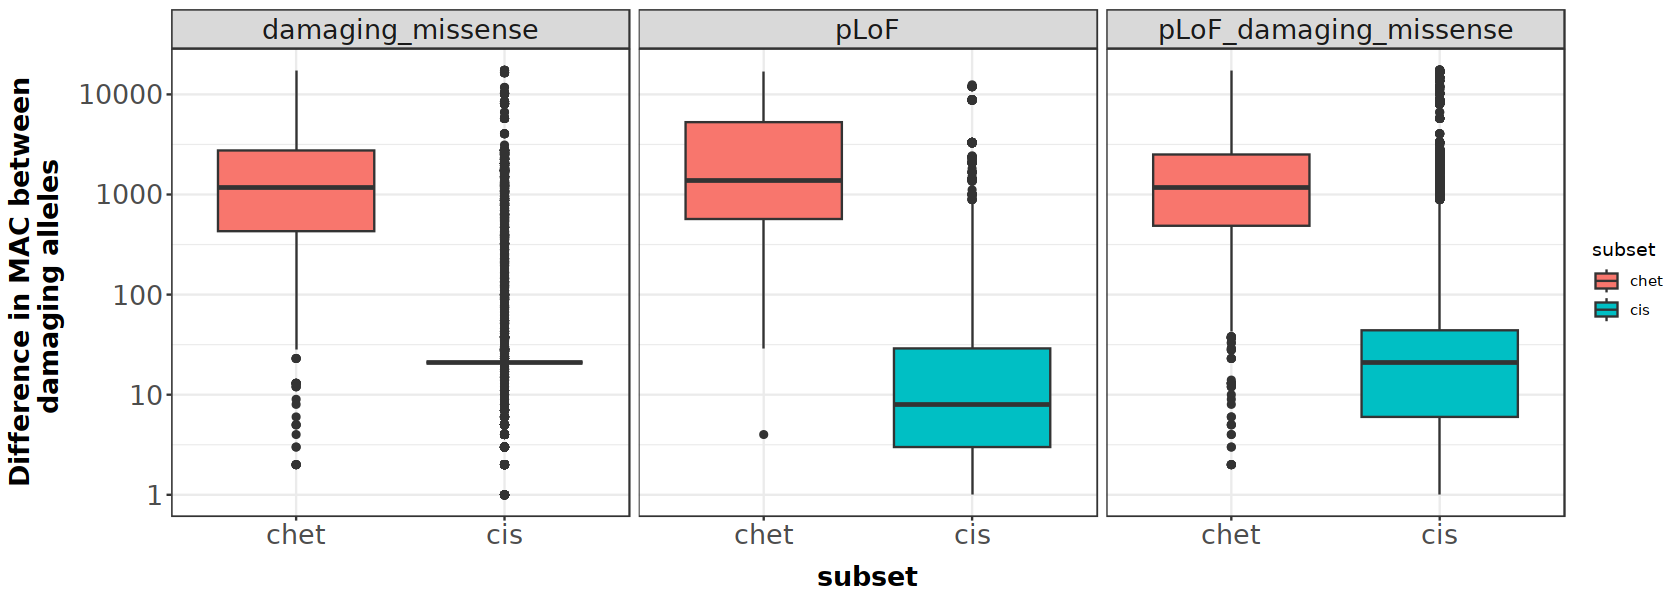

In [180]:
options(repr.plot.width=14, repr.plot.height=5)
ggplot(ac_count_test, aes(y=delta_ac, x=subset, fill=subset)) +
    geom_boxplot() +
    scale_y_continuous(trans="log10") +
    theme_bw() +
    ylab("Difference in MAC between\ndamaging alleles ") +
    theme(
        legend.position = "right",
        strip.text = element_text(size=16),
        axis.text=element_text(size=16),
        axis.title=element_text(size=16,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
    ) + 
    facet_wrap(~annotation)

In [181]:
ggsave("derived/plots/230325_bi_allelic_disruption_boxplot.pdf", width=12, height=5)

Warning message:
"Transformation introduced infinite values in continuous y-axis"
Warning message:
"Removed 40351 rows containing non-finite values (`stat_boxplot()`)."


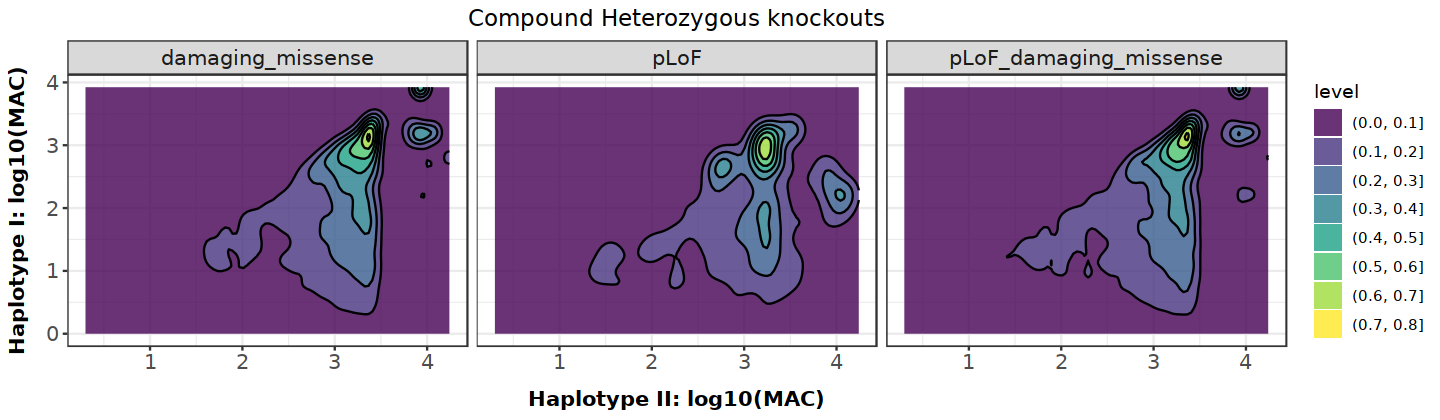

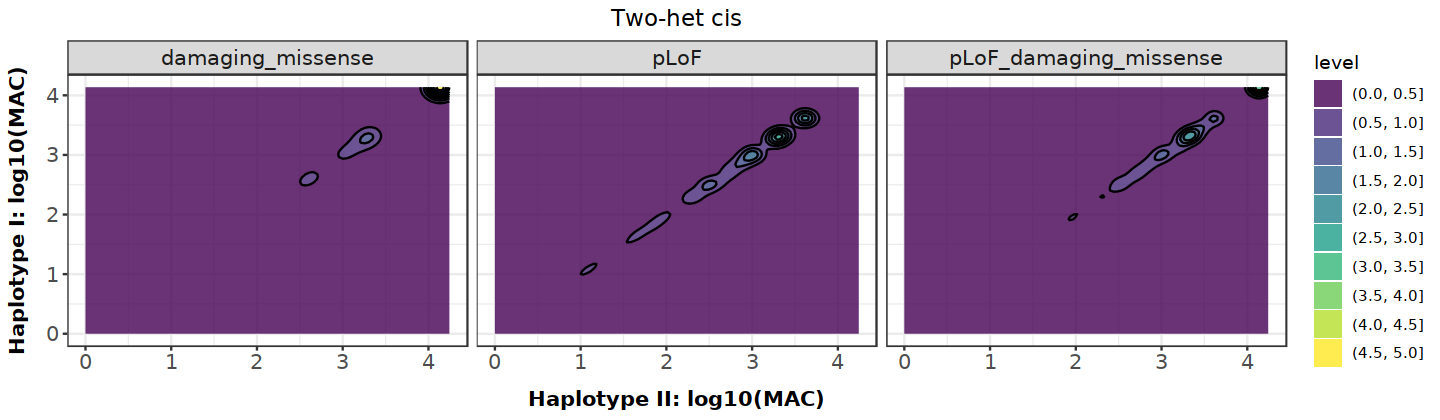

In [38]:
options(repr.plot.width=12, repr.plot.height=3.5)
print(p1)
print(p2)

In [64]:
grepl("fox","the fox crossed the")

[1] TRUE

## 3.4 Compound het exon utilisation

In [ ]:
exon_usage <- do.call(rbind, lapply(full$exon, function(x){
    splitted <- unlist(strsplit(x, split = ';'))
    mut1 <- as.numeric(unlist(strsplit(splitted[1], split = "/")))
    mut2 <- as.numeric(unlist(strsplit(splitted[2], split = "/")))
    total_exons <- mut1[2]
    exon1 <- mut1[1]
    exon2 <- mut2[1]
    return(data.frame(exon1, exon2, total_exons))
}))

In [ ]:
full$exons_between <- abs(full$exon1 - full$exon2)
full$exon1_gene_loc <- full$exon1 / full$total_exons
full$exon2_gene_loc <- full$exon2 / full$total_exons

# 3.0 Geneset comparison

In [3]:
library(MASS) # for glm.nb
library(pscl) # for zinf
library(ggplot2)
library(data.table)

## 3.1 GTEx negative binomial regression

In [20]:
dt <- fread("data/knockouts/tables/combined_annotations_by_sample.nohets.txt.gz")

In [11]:
# load GTEx categories
gtex <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/gtex/GTEx.tstat.tsv")
gtex <- cbind(ensembl_gene_id = gtex$ENSGID, apply(gtex[,-1], 2, function(x) x > quantile(x, probs = 0.9)))
colnames(gtex) <- tolower(gsub("_\\s*\\([^\\)]+\\)","",colnames(gtex)))
                        
# categories to merge on
gtex_categories <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/gtex/GTEX.tstat.categories.genoppi.csv")
gtex_categories$id <- tolower(gsub("_\\s*\\.[^\\.]+\\.","",gtex_categories$Tissue.genoppi))
gtex_categories$id <- gsub("[0-9]\\.$","",gtex_categories$id)
gtex_categories$id <- gsub("\\.","-",gtex_categories$id)
stopifnot(sum(!gtex_categories$id %in% colnames(gtex)) == 0)

In [12]:
# get transcript
transcript <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/221216_enstid_ensgid_lengths.txt.gz")
transcript <- transcript[,c("ensembl_gene_id", "ensembl_transcript_id", "hgnc_symbol", "chromosome_name", "length")]
transcript$length <- (transcript$length-mean(transcript$length))/sd(transcript$length)
transcript$length2 <- transcript$length ^ 2

# get GC-content
dgc <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/221229_ensgid_gc_content.txt.gz")
dgc$gc <- dgc$percentage_gene_gc_content
dgc$gc_norm <- (dgc$gc - mean(dgc$gc))/sd(dgc$gc)
dgc$percentage_gene_gc_content <- NULL
dgc_transcript <- merge(transcript, dgc, all.x = TRUE, by = c("ensembl_gene_id"))

# get mutation rate
mut <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/mutation_rates/samocha2014.txt.gz")
geneset <- merge(dgc_transcript, mut, by = c("ensembl_gene_id","hgnc_symbol"), all.x = TRUE)

In [13]:
annotations <- c("pLoF","damaging_missense","pLoF_damaging_missense","other_missense","synonymous")
categories <- colnames(gtex)[-1]

In [20]:
outer_list <- lapply(annotations, function(anno){
    print(anno)
    # subset main data and get homs/cis
    dt_subset <- dt[dt$annotation == anno,]
    lst_data <- list(
        chets = dt_subset[(dt_subset$is_chet | dt_subset$is_cis),],
        homzygotes = dt_subset[(dt_subset$is_hom | dt_subset$is_cis),]
    )

    # get OR/P-values for each dataset
    lst <- lapply(names(lst_data), function(dt_name) {

        print(paste('-',dt_name))
        full <- lst_data[[dt_name]]
        aggr_ko <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=sum)
        aggr_full <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=length)
        aggr <- merge(aggr_ko, aggr_full, by = c("ensembl_gene_id","ensembl_transcript_id"))
        colnames(aggr) <- c("ensembl_gene_id","ensembl_transcript_id", "n","total")
        
        mrg <- merge(aggr, geneset, by = c("ensembl_gene_id", "ensembl_transcript_id"), all.x = TRUE)
        mrg <- merge(mrg, gtex, all.x=TRUE, by = "ensembl_gene_id")
        
        
        lst <- lapply(categories, function(category){
            
            print(paste0("--",category))
            dt_fit <- mrg
            na_rows <- rowSums(is.na(dt_fit[,c('n','length', "gc_norm")]))
            dt_fit <- dt_fit[!na_rows,]
            dt_fit$x <- dt_fit[[category]]
            
            model <- as.formula(paste0("n~x+length+gc_norm"))#,get_mut_rate_label(anno)))
            x <- glm.nb(model, data = dt_fit, link = "log",  control=glm.control(maxit=100))
            
            fit <- data.frame(coef(summary(x)))
            colnames(fit) <- c("est", "error", "z", "p")
            conf <- suppressMessages(exp(cbind(coef(x), confint(x))))
            
            fit$ci_est <- conf[,1]
            fit$ci_lower <- conf[,2]
            fit$ci_upper <- conf[,3]

            
            fit$keep <- as.logical(c(0, 1, 0, 0))
            fit$id <- category
            rownames(fit) <- NULL
            return(fit)
        })

        out <- do.call(rbind, lst)
        out$dt_name <- dt_name
        return(out)
    })

    # combine the data into a single data.frame
    d1 <- lst[[1]]
    d1 <- d1[d1$keep == 1, ]
    d2 <- lst[[2]]
    d2 <- d2[d2$keep == 1, ]
    colnames(d1)[1:8] <- paste0("hom_",colnames(d1)[1:8])
    colnames(d2)[1:8] <- paste0("chet_",colnames(d2)[1:8])
    d <- merge(d1, d2, by = "id")
    d$annotation <- anno
    
    return(d)
})

[1] "synonymous"
[1] "- chets"
[1] "--adipose_subcutaneous"
[1] "--adipose_visceral"
[1] "--adrenal_gland"
[1] "--artery_aorta"
[1] "--artery_coronary"
[1] "--artery_tibial"
[1] "--bladder"
[1] "--brain_amygdala"
[1] "--brain_anterior_cingulate_cortex"
[1] "--brain_caudate"
[1] "--brain_cerebellar_hemisphere"
[1] "--brain_cerebellum"
[1] "--brain_cortex"
[1] "--brain_frontal_cortex"
[1] "--brain_hippocampus"
[1] "--brain_hypothalamus"
[1] "--brain_nucleus_accumbens"
[1] "--brain_putamen"
[1] "--brain_spinal_cord"
[1] "--brain_substantia_nigra"
[1] "--breast_mammary_tissue"
[1] "--cells_ebv-transformed_lymphocytes"
[1] "--cells_transformed_fibroblasts"
[1] "--cervix_ectocervix"
[1] "--cervix_endocervix"
[1] "--colon_sigmoid"
[1] "--colon_transverse"
[1] "--esophagus_gastroesophageal_junction"
[1] "--esophagus_mucosa"
[1] "--esophagus_muscularis"
[1] "--fallopian_tube"
[1] "--heart_atrial_appendage"
[1] "--heart_left_ventricle"
[1] "--kidney_cortex"
[1] "--liver"
[1] "--lung"
[1] "--mino

In [189]:
# combine in "long" format
d <- do.call(rbind, outer_list)
d1 <- d[,c("id","hom_est", "hom_error", "hom_z", "hom_p", "hom_ci_est", "hom_ci_lower", "hom_ci_upper", "annotation")]
d2 <- d[,c("id","chet_est", "chet_error", "chet_z", "chet_p", "chet_ci_est", "chet_ci_lower", "chet_ci_upper", "annotation")]
colnames(d1) <- gsub("hom_", "", colnames(d1))
colnames(d2) <- gsub("chet_", "", colnames(d2))
d1$dt_name <- "homs"
d2$dt_name <- "chets"
dout <- rbind(d1, d2)

# get gtex categories
dout <- merge(dout, gtex_categories, all.x = TRUE)

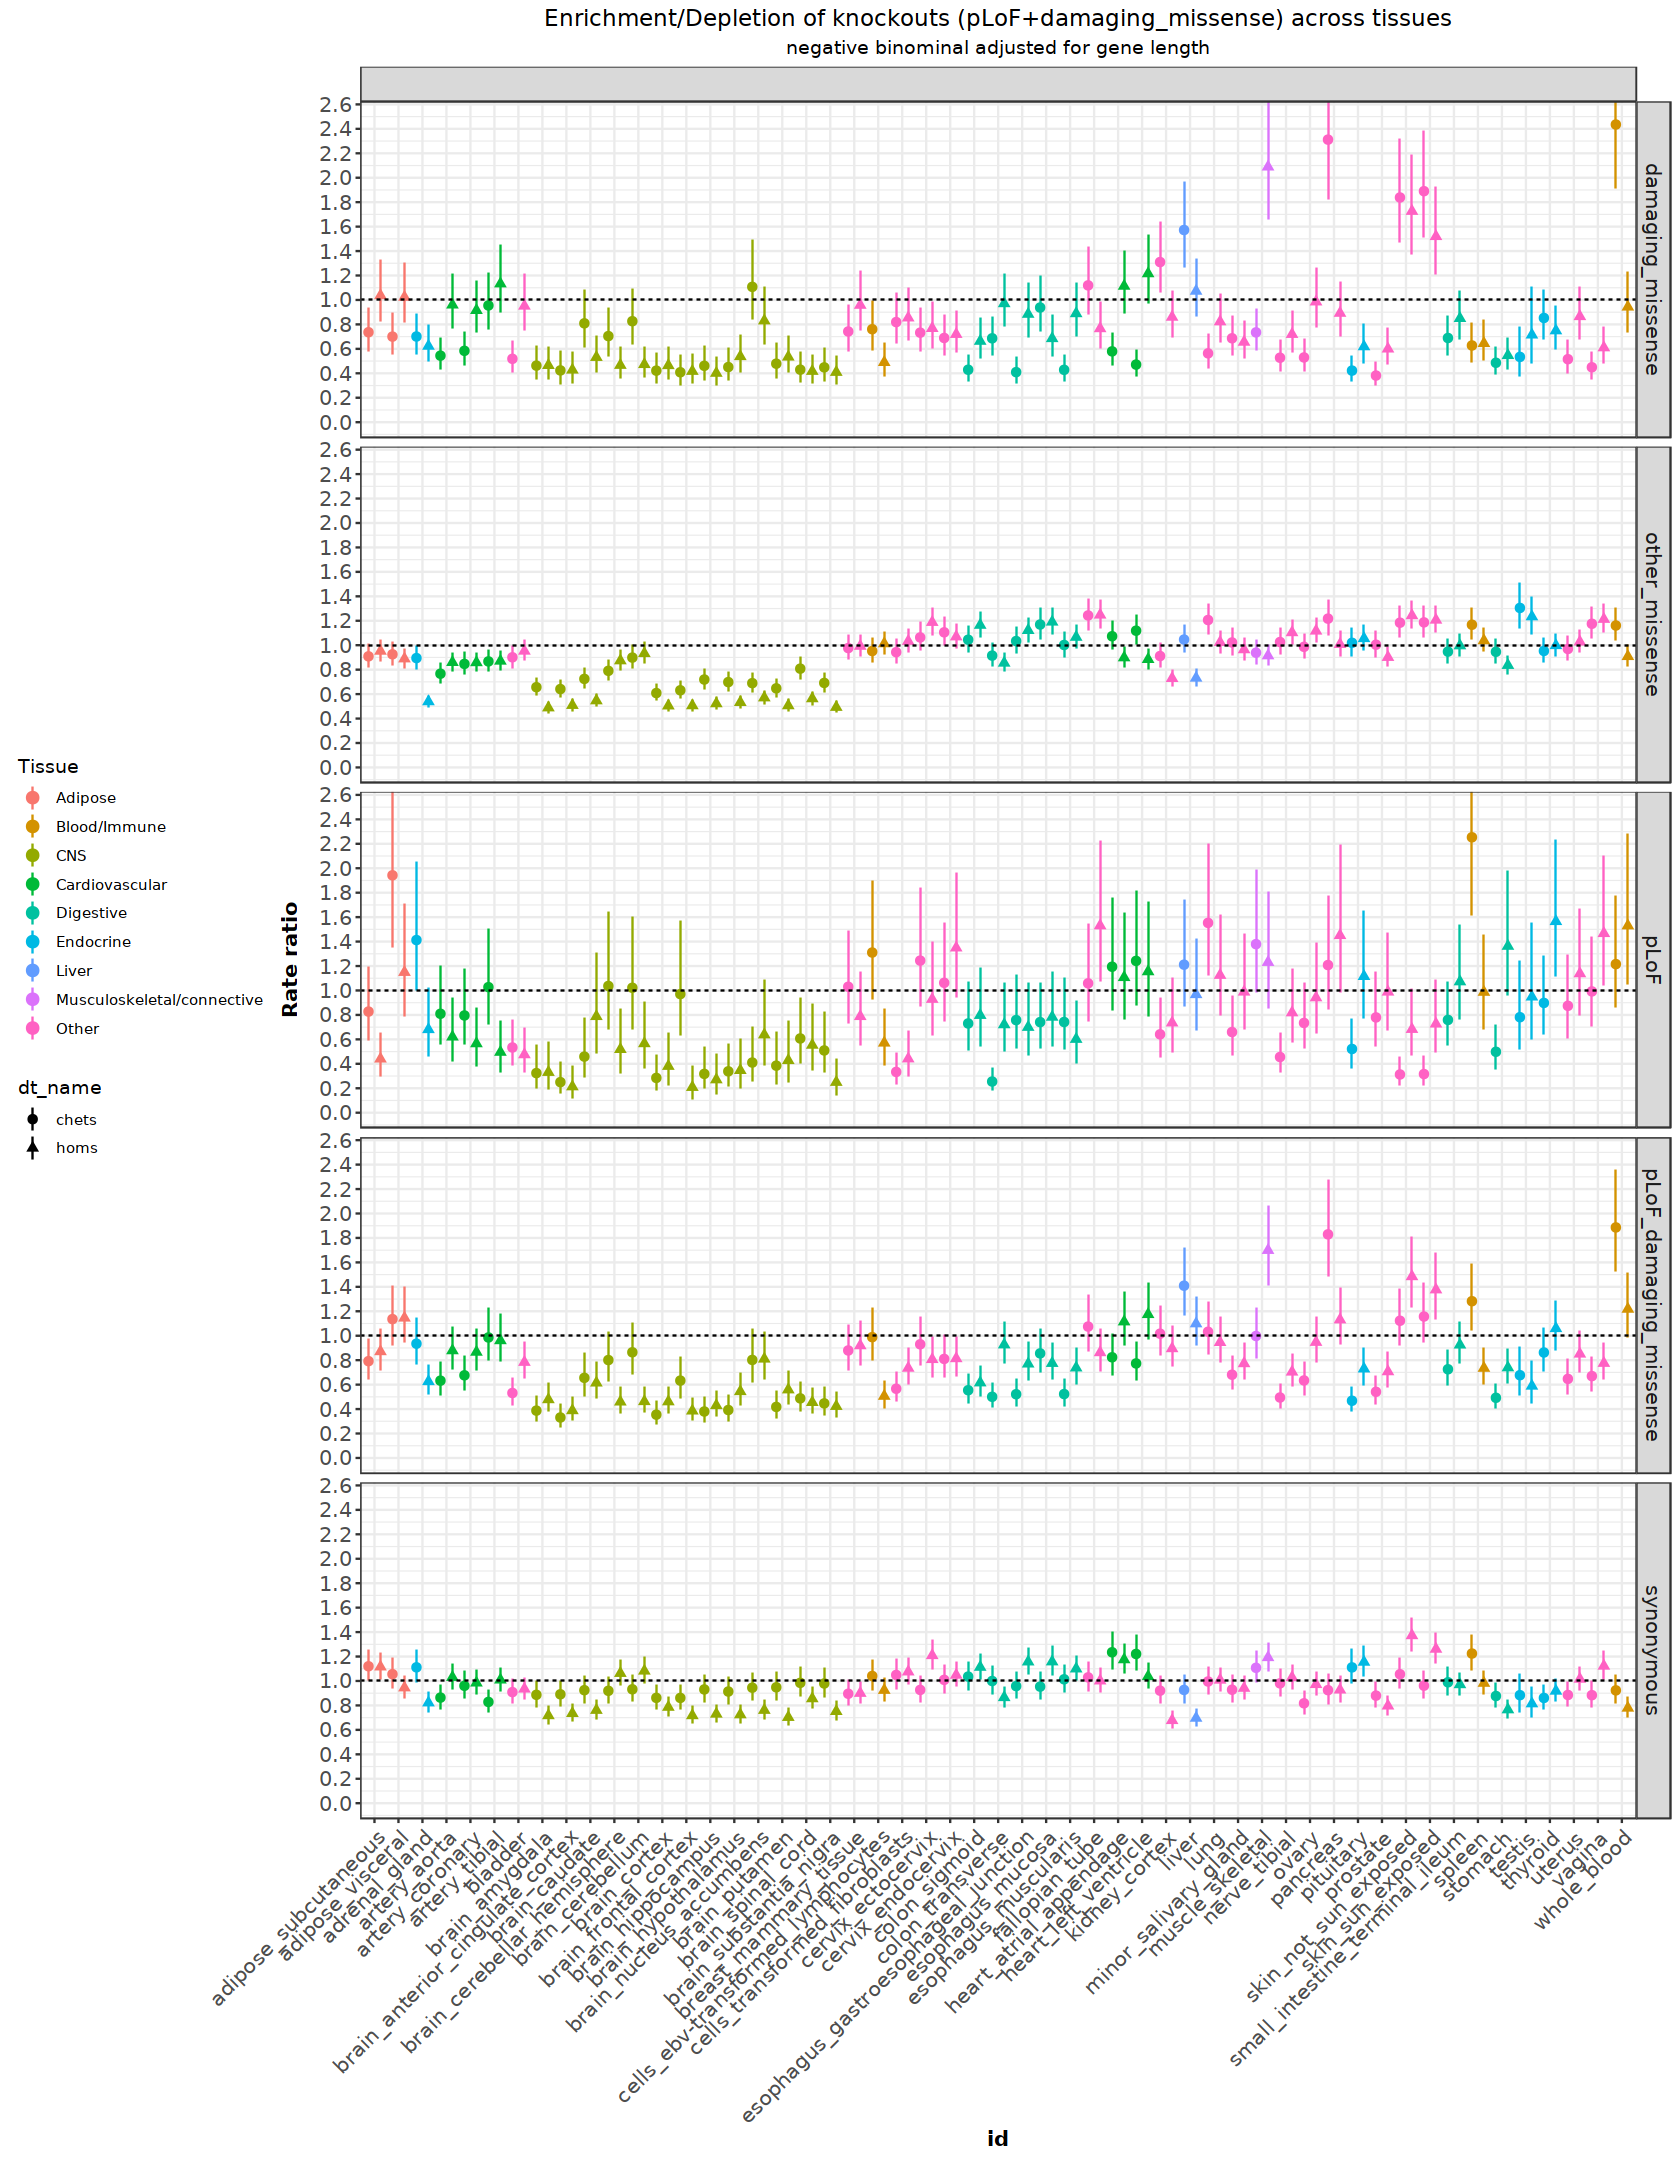

In [190]:
options(repr.plot.width=14, repr.plot.height=18)
title <- "Enrichment/Depletion of knockouts (pLoF+damaging_missense) across tissues"
subtitle <- "negative binominal adjusted for gene length"
pd <- position_dodge(1)
ggplot(dout, aes(x=id, y=ci_est, ymin=ci_lower, ymax=ci_upper, color=Tissue.category.for.display, 
                 group=dt_name, shape=dt_name)) +
    geom_pointrange(position = pd) +
    geom_hline(yintercept = 1, linetype = 'dashed') +
    ggtitle(title, subtitle) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    coord_cartesian(ylim = c(0,2.5)) +
    labs(color = "Tissue") +
    theme_bw() +
    ylab("Rate ratio") +
        theme(
        legend.position = "left",
        strip.text = element_text(size=12),
        axis.text=element_text(size=12),
        axis.title=element_text(size=12,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 45, hjust = 0.99, vjust = 0.99),
    ) +
    facet_grid(annotation~"")

#ggplot(fits, aes(y=id, x=est_exp, xmin=est-error, xmax=est+error, color=Tissue.category.for.display)) +

### 3.1 Modelling by gene P-value bins

In [49]:
# retrive them
pLoF <- read_ukb_wes_kos("pLoF")
damaging_missense <- read_ukb_wes_kos("damaging_missense")
pLoF_damaging_missense <- read_ukb_wes_kos("pLoF_damaging_missense")

# annotate
pLoF$annotation <- "pLoF"
damaging_missense$annotation <- "damaging_missense"
pLoF_damaging_missense$annotation <- "pLoF_damaging_missense"

In [50]:
# keep only relevant columns
cols_to_keep <- c("gene_id","s","knockout","annotation", "pKO", "chromosome", "transcript_id")
dt <- setDT(rbind(pLoF, damaging_missense, pLoF_damaging_missense, other_missense, synonymous))
dt <- dt[!(dt$knockout %in% "Heterozygote"), ]
dt <- dt[,colnames(dt) %in% cols_to_keep, with = FALSE]

# format
dt$is_chet <- dt$knockout %in% "Compound heterozygote"
dt$is_cis <- dt$knockout %in% "Compound heterozygote (cis)"
dt$is_hom <- dt$knockout %in% "Homozygote"
dt$is_ko <- dt$is_hom | dt$is_chet
dt$knockout <- NULL

# exclude common knockoiuts
counts <- data.table(table(dt$is_ko, dt$gene_id))
counts <- counts[counts$V1 == TRUE,]
counts <- counts[rev(order(counts$N))]
gene_id_exclude <- counts$V2[counts$N > 10000]
dt <- dt[!(dt$gene_id %in% gene_id_exclude),]

ERROR: Error in lapply(list(...), function(x) if (is.list(x)) x else as.data.table(x)): object 'other_missense' not found


## 3.2 Modelling by REACTOME

In [22]:
library(genoppi)

In [29]:
dt <- fread("data/knockouts/tables/combined_annotations_by_sample.nohets.txt.gz")

In [30]:
# get transcript
transcript <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/221216_enstid_ensgid_lengths.txt.gz")
transcript <- transcript[,c("ensembl_gene_id", "ensembl_transcript_id", "hgnc_symbol", "chromosome_name", "length")]
transcript$length <- (transcript$length-mean(transcript$length))/sd(transcript$length)
transcript$length2 <- transcript$length ^ 2

# get GC-content
dgc <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/221229_ensgid_gc_content.txt.gz")
dgc$gc <- dgc$percentage_gene_gc_content
dgc$gc_norm <- (dgc$gc - mean(dgc$gc))/sd(dgc$gc)
dgc$percentage_gene_gc_content <- NULL
dgc_transcript <- merge(transcript, dgc, all.x = TRUE, by = c("ensembl_gene_id"))

# get mutation rate
mut <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/mutation_rates/samocha2014.txt.gz")
geneset <- merge(dgc_transcript, mut, by = c("ensembl_gene_id","hgnc_symbol"), all.x = TRUE)

In [69]:
hgnc_to_ensembl <- get_mapping_hgnc_to_ensembl()
# set up kegg
kegg <- msigdb_c2_table[grepl('KEGG', msigdb_c2_table$Set.name),]
colnames(kegg) <- c("hgnc_symbol", "geneset")
kegg$ensembl_gene_id <- hgnc_to_ensembl[kegg$hgnc_symbol]
rownames(kegg) <- NULL

# set up reactome
reactome <- msigdb_c2_table[grepl("REACTOME", msigdb_c2_table$Set.name),]
colnames(reactome) <- c("hgnc_symbol", "geneset")
reactome$ensembl_gene_id <- hgnc_to_ensembl[reactome$hgnc_symbol]
rownames(reactome) <- NULL

# combine
kegg_reactome <- rbind(kegg, reactome)
kegg_reactome$hgnc_symbol <- NULL
kegg_reactome <- head(kegg_reactome, n = 1000)

In [70]:
annotations <- c("pLoF","damaging_missense","pLoF_damaging_missense","other_missense","synonymous")
categories <- unique(kegg_reactome$geneset)

In [92]:
outer_list <- lapply(annotations, function(anno){
    print(anno)
    # subset main data and get homs/cis
    dt_subset <- dt[dt$annotation == anno,]
    lst_data <- list(
        chets = dt_subset[(dt_subset$is_chet | dt_subset$is_cis),],
        homzygotes = dt_subset[(dt_subset$is_hom | dt_subset$is_cis),]
    )

    # get OR/P-values for each dataset
    lst <- lapply(names(lst_data), function(dt_name) {

        print(paste('-',dt_name))
        full <- lst_data[[dt_name]]
        aggr_ko <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=sum)
        aggr_full <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=length)
        aggr <- merge(aggr_ko, aggr_full, by = c("ensembl_gene_id","ensembl_transcript_id"))
        colnames(aggr) <- c("ensembl_gene_id","ensembl_transcript_id", "n","total")
        mrg <- merge(aggr, geneset, by = c("ensembl_gene_id", "ensembl_transcript_id"), all.x = TRUE)

        
        lst <- lapply(categories, function(category){
            
            print(paste0("--",category))
            genes_in_category <- unique(kegg_reactome$ensembl_gene_id[kegg_reactome$geneset == category])
            dt_fit <- mrg
            dt_fit$x <- dt_fit$ensembl_gene_id %in% genes_in_category
            na_rows <- rowSums(is.na(dt_fit[,c('n','length', "gc_norm")]))

            fit <- NULL
            
            if (sum(dt_fit$x) > 1){
            #    tryCatch({
                 
                model <- as.formula(paste0("n~x+length+gc_norm"))#,get_mut_rate_label(anno)))
                x <- glm.nb(model, data = dt_fit, link = "log",  control=glm.control(maxit=100))
                fit <- data.frame(coef(summary(x)))
                colnames(fit) <- c("est", "error", "z", "p")
                #print(fit)
                #conf <- suppressMessages(exp(cbind(coef(x), confint(x))))

                #fit$ci_est <- conf[,1]
                #fit$ci_lower <- conf[,2]
                #fit$ci_upper <- conf[,3]
                fit$keep <- as.logical(c(0, 1, 0, 0))
                fit$id <- category
                rownames(fit) <- NULL
            #  }, error=function(e){cat("ERROR :",conditionMessage(e), "\n")})

            return(fit)
            }
        })

        out <- do.call(rbind, lst)
        out$dt_name <- dt_name
        return(out)
    })

    # combine the data into a single data.frame
    d1 <- lst[[1]]
    d1 <- d1[d1$keep == 1, ]
    d2 <- lst[[2]]
    d2 <- d2[d2$keep == 1, ]
    d <- rbind(d1, d2)
    d$annotation <- anno
    
    return(d)
})

[1] "pLoF"
[1] "- chets"
[1] "--KEGG_GLYCOLYSIS_GLUCONEOGENESIS"
[1] "--KEGG_CITRATE_CYCLE_TCA_CYCLE"
[1] "--KEGG_PENTOSE_PHOSPHATE_PATHWAY"
[1] "--KEGG_PENTOSE_AND_GLUCURONATE_INTERCONVERSIONS"
[1] "--KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM"
[1] "--KEGG_GALACTOSE_METABOLISM"
[1] "--KEGG_ASCORBATE_AND_ALDARATE_METABOLISM"
[1] "--KEGG_FATTY_ACID_METABOLISM"
[1] "--KEGG_STEROID_BIOSYNTHESIS"
[1] "--KEGG_PRIMARY_BILE_ACID_BIOSYNTHESIS"
[1] "--KEGG_STEROID_HORMONE_BIOSYNTHESIS"
[1] "--KEGG_OXIDATIVE_PHOSPHORYLATION"
[1] "--KEGG_PURINE_METABOLISM"
[1] "--KEGG_PYRIMIDINE_METABOLISM"
[1] "--KEGG_ALANINE_ASPARTATE_AND_GLUTAMATE_METABOLISM"
[1] "--KEGG_GLYCINE_SERINE_AND_THREONINE_METABOLISM"
[1] "--KEGG_CYSTEINE_AND_METHIONINE_METABOLISM"
[1] "--KEGG_VALINE_LEUCINE_AND_ISOLEUCINE_DEGRADATION"
[1] "--KEGG_VALINE_LEUCINE_AND_ISOLEUCINE_BIOSYNTHESIS"
[1] "--KEGG_LYSINE_DEGRADATION"
[1] "--KEGG_ARGININE_AND_PROLINE_METABOLISM"
[1] "- homzygotes"
[1] "--KEGG_GLYCOLYSIS_GLUCONEOGENESIS"
[1] "--KEGG_CIT

In [96]:
d <- do.call(rbind, outer_list)
d$keep <- FALSE

## 3.2.A Modelling by loeuf

In [29]:
dt <- fread("data/knockouts/tables/combined_annotations_by_sample.nohets.txt.gz")
dt_subset <- dt[dt$annotation == "pLoF_damaging_missense", ]
aggr_chet <- aggregate(is_chet ~ ensembl_gene_id + ensembl_transcript_id, data = dt_subset, FUN=sum)
aggr_cis <- aggregate(is_cis ~ ensembl_gene_id + ensembl_transcript_id, data = dt_subset, FUN=sum)
aggr_hom <- aggregate(is_hom ~ ensembl_gene_id + ensembl_transcript_id, data = dt_subset, FUN=sum)
aggr_ko <- aggregate(is_ko ~ ensembl_gene_id + ensembl_transcript_id, data = dt_subset, FUN=sum)
aggr <- merge(aggr_chet, aggr_hom, all = TRUE)
aggr <- merge(aggr, aggr_cis, all = TRUE)
aggr <- merge(aggr, aggr_ko, all = TRUE)

In [121]:
# get LOEUF scores
loeuf <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/gnomad/karczewski2020/supplementary_dataset_11_full_constraint_metrics.tsv")
loeuf <- loeuf[loeuf$canonical,]
cols_to_keep <- c('gene_id','transcript','oe_lof_upper_bin','oe_lof_upper')
loeuf <- loeuf[,colnames(loeuf) %in% cols_to_keep, with = FALSE]
colnames(loeuf)[colnames(loeuf) == "gene_id"] <- "ensembl_gene_id"
colnames(loeuf)[colnames(loeuf) == "gene"] <- "hgnc_symbol"
colnames(loeuf)[colnames(loeuf) == "transcript"] <- "ensembl_transcript_id"
colnames(loeuf)[colnames(loeuf) == "oe_lof_upper"] <- "loeuf"

# get transcript
transcript <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/221216_enstid_ensgid_lengths.txt.gz")
transcript <- transcript[,c("ensembl_gene_id", "ensembl_transcript_id", "hgnc_symbol", "chromosome_name", "length")]
transcript$length <- (transcript$length-mean(transcript$length))/sd(transcript$length)
transcript$length2 <- transcript$length ^ 2
transcript_loeuf <- merge(loeuf, transcript, by = c("ensembl_gene_id", "ensembl_transcript_id"), all.x = TRUE)

# get GC-content
dgc <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/221229_ensgid_gc_content.txt.gz")
dgc$gc <- dgc$percentage_gene_gc_content
dgc$gc_norm <- (dgc$gc - mean(dgc$gc))/sd(dgc$gc)
dgc$percentage_gene_gc_content <- NULL
dgc_transcript_loeuf <- merge(transcript_loeuf, dgc, all.x = TRUE, by = c("ensembl_gene_id"))

# get mutation rate
mut <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/mutation_rates/samocha2014.txt.gz")
geneset <- merge(dgc_transcript_loeuf, mut, by = c("ensembl_gene_id","hgnc_symbol"), all.x = TRUE)

In [122]:
genes <- transcript_loeuf[,c("ensembl_gene_id","ensembl_transcript_id")]
genes <- genes[!duplicated(genes),]
genes <- genes[!(genes$ensembl_gene_id %in% aggr$ensembl_gene_id)]
genes$is_chet <- NA
genes$is_hom <- NA
genes$is_cis <- NA
nrow(genes)

[1] 8588

In [123]:
aggr <- rbind(aggr, genes)
aggr$is_chet[is.na(aggr$is_chet)] <- 0
aggr$is_hom[is.na(aggr$is_hom)] <- 0
aggr$is_cis[is.na(aggr$is_cis)] <- 0
nrow(aggr)

[1] 20045

In [124]:
mrg <- merge(aggr, geneset, all.x = TRUE)
final <- mrg[!is.na(mrg$length2),]
categories <- unique(na.omit(loeuf$oe_lof_upper_bin))
annotations <- c("pLoF","damaging_missense","pLoF_damaging_missense","other_missense","synonymous")

In [125]:
final$total <- final$is_chet + final$is_hom + final$is_cis
final$total <- (final$total - mean(final$total, na.rm = TRUE))/sd(final$total, na.rm = TRUE)
final <- final[(final$is_chet > 0) | (final$is_cis > 0),]

In [131]:
var(final$is_chet)/mean(final$is_chet)
var(final$is_cis)/mean(final$is_cis)

[1] 751.9678

[1] 6849.207

In [116]:
lst <- lapply(categories, function(category){

    print(category)
    dt_fit <- final
    dt_fit$x <- FALSE
    dt_fit$x[dt_fit$oe_lof_upper_bin == category] <- TRUE

    model <- as.formula(paste0("is_chet~x+length+gc_norm"))
    x <- glm.nb(model, data = dt_fit, link = "log",  control=glm.control(maxit=100))

    fit <- data.frame(coef(summary(x)))
    colnames(fit) <- c("est", "error", "z", "p")
    conf <- suppressMessages(exp(cbind(coef(x), confint(x))))

    fit$ci_est <- conf[,1]
    fit$ci_lower <- conf[,2]
    fit$ci_upper <- conf[,3]

    fit$keep <- as.logical(c(0, 1, 0, 0))
    fit$id <- category
    rownames(fit) <- NULL
    return(fit)
})



[1] 6
[1] 4
[1] 2
[1] 5
[1] 8
[1] 3
[1] 9
[1] 0
[1] 1
[1] 7


In [117]:
out <- do.call(rbind, lst)
out$annotation <- "pLoF"
out$dt_name <- "chets"
out <- out[out$keep, ]
ids <- sort(unique(out$id))
out$loeuf <- factor(unlist(lapply(ids, function(id) paste0(id,'-',id+1))))

In [118]:
colfunc <- colorRampPalette(c("tomato2", "lightblue"))
my_colors <- colfunc(length(unique(out$id)))
names(my_colors) <- levels(out$loeuf)
fill_scale <- scale_fill_manual(name = "loeuf", values = my_colors)
color_scale <- scale_color_manual(name = "loeuf", values = my_colors)

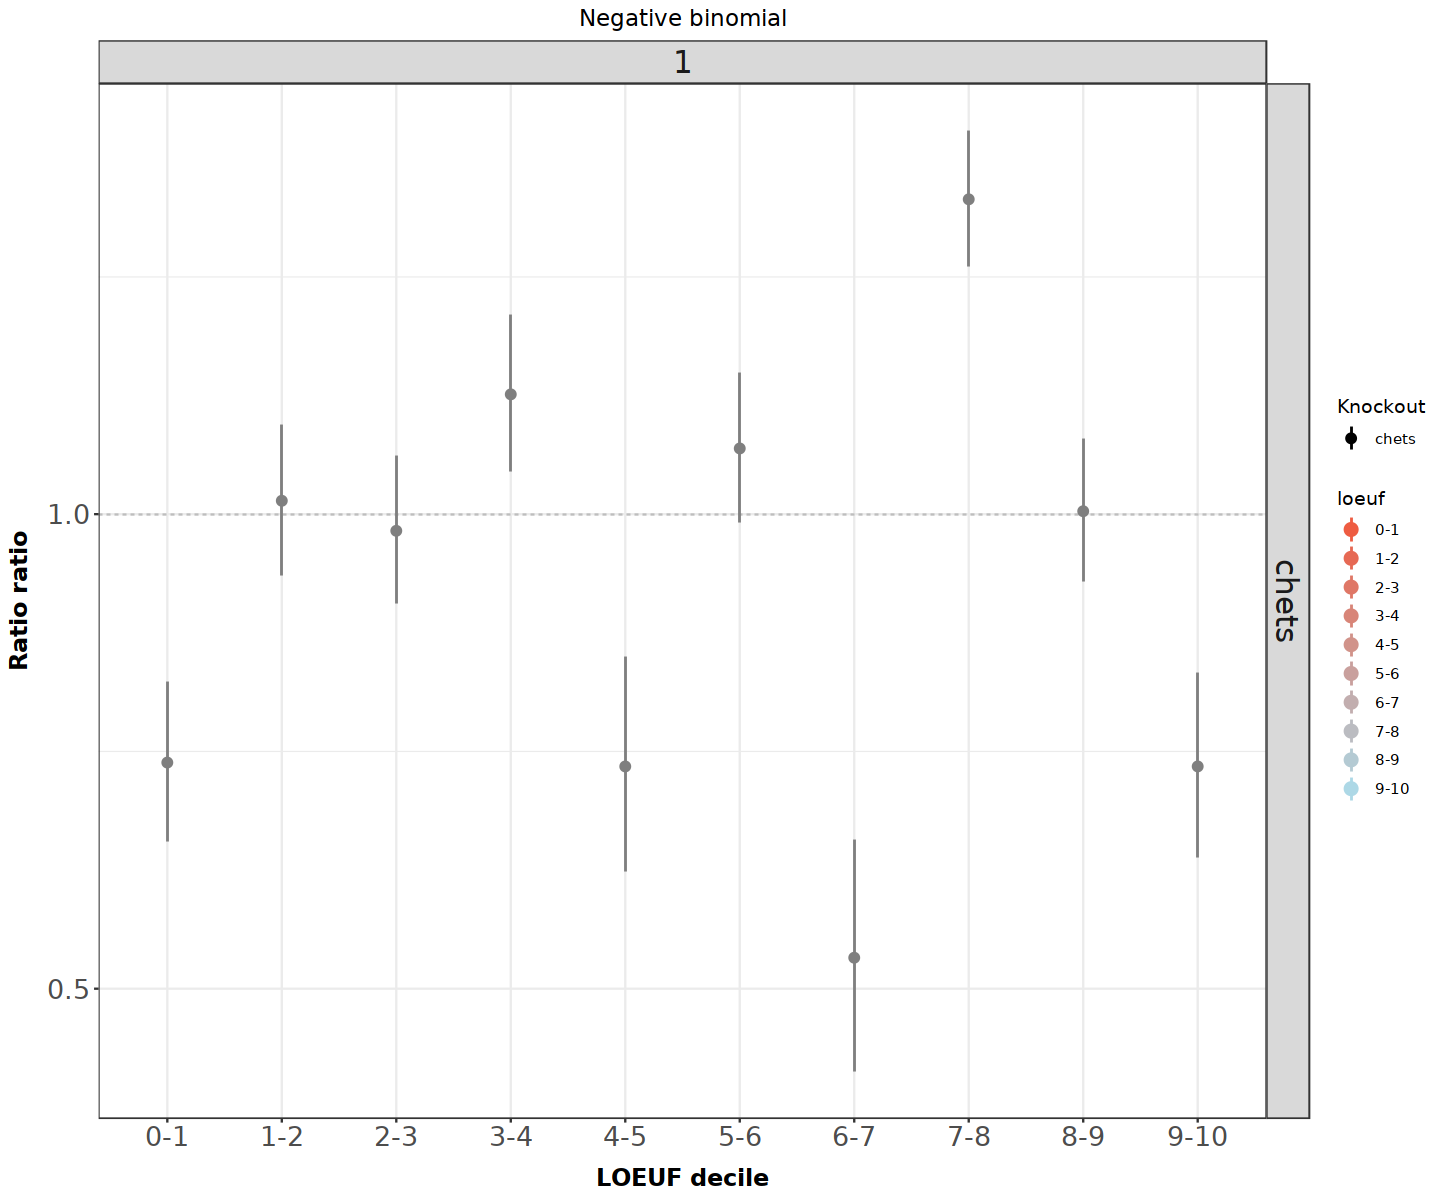

In [119]:
options(repr.plot.width=12, repr.plot.height=10)
pd <- position_dodge(0.7)
ggplot(out, aes(
             x=loeuf,
             y=ci_est, 
             ymin=ci_lower, 
             ymax=ci_upper, 
             color=annotation,
             group=annotation,
             shape=dt_name
            )
      ) +
    geom_hline(yintercept = 1, linetype = 'dashed', color = "grey") +
    geom_pointrange(position = pd, size = 0.6) +
    scale_y_continuous(
        #breaks=scales::pretty_breaks(n=5), 
        trans="log10",
        breaks=c(0.1, 0.25, 0.5, 1, 2, 4, 8)
    ) +
    #coord_cartesian(ylim=c(0, 5)) +
    xlab("LOEUF decile") + 
    ylab("Ratio ratio") +
    color_scale + 
    theme_bw() +
    labs(shape="Knockout", color = "Annotation") +
    ggtitle("Negative binomial") +
        theme(
        legend.position = "right",
        strip.text = element_text(size=18),
        axis.text=element_text(size=16),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        #panel.background = element_blank(),
        #panel.grid.major = element_blank(), 
        #panel.grid.minor = element_blank()
    ) +
    facet_grid(dt_name~1)


### 3.2 Modelling by LOEUF

In [11]:
dt <- fread("data/knockouts/tables/combined_annotations_by_sample.nohets.txt.gz")




In [12]:
# get LOEUF scores
loeuf <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/gnomad/karczewski2020/supplementary_dataset_11_full_constraint_metrics.tsv")
loeuf <- loeuf[loeuf$canonical,]
cols_to_keep <- c('gene_id','transcript','oe_lof_upper_bin','oe_lof_upper')
loeuf <- loeuf[,colnames(loeuf) %in% cols_to_keep, with = FALSE]
colnames(loeuf)[colnames(loeuf) == "gene_id"] <- "ensembl_gene_id"
colnames(loeuf)[colnames(loeuf) == "gene"] <- "hgnc_symbol"
colnames(loeuf)[colnames(loeuf) == "transcript"] <- "ensembl_transcript_id"
colnames(loeuf)[colnames(loeuf) == "oe_lof_upper"] <- "loeuf"

# get transcript
transcript <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/221216_enstid_ensgid_lengths.txt.gz")
transcript <- transcript[,c("ensembl_gene_id", "ensembl_transcript_id", "hgnc_symbol", "chromosome_name", "length")]
transcript$length <- (transcript$length-mean(transcript$length))/sd(transcript$length)
transcript$length2 <- transcript$length ^ 2
transcript_loeuf <- merge(loeuf, transcript, by = c("ensembl_gene_id", "ensembl_transcript_id"), all.x = TRUE)

# get GC-content
dgc <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/221229_ensgid_gc_content.txt.gz")
dgc$gc <- dgc$percentage_gene_gc_content
dgc$gc_norm <- (dgc$gc - mean(dgc$gc))/sd(dgc$gc)
dgc$percentage_gene_gc_content <- NULL
dgc_transcript_loeuf <- merge(transcript_loeuf, dgc, all.x = TRUE, by = c("ensembl_gene_id"))

# get mutation rate
mut <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/mutation_rates/samocha2014.txt.gz")
geneset <- merge(dgc_transcript_loeuf, mut, by = c("ensembl_gene_id","hgnc_symbol"), all.x = TRUE)

In [13]:
categories <- unique(na.omit(loeuf$oe_lof_upper_bin))
annotations <- c("pLoF","damaging_missense","pLoF_damaging_missense","other_missense","synonymous")

In [17]:
get_mut_rate_label <- function(x){
    if (x=="pLoF") {
        return("frameshift")
    } else if (x=="pLoF_damaging_missense"){
        return("mis")
    } else if (x=="damaging_missense"){
        return("mis")
    } else if (x=="other_missense"){
        return("mis")
    } else if (x=="synonymous"){
        return("syn")
    } else {
        stop(paste(x, " is not valid!"))
    }
}

In [26]:
anno <- "synonymous"
dt_subset <- dt[dt$annotation == anno,]
lst_data <- list(chets = dt_subset[(dt_subset$is_chet | dt_subset$is_cis),])
dt_name <- "chets"
full <- lst_data[[dt_name]]
aggr_ko <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=sum)
aggr_full <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=length)
aggr <- merge(aggr_ko, aggr_full, by = c("ensembl_gene_id","ensembl_transcript_id"))
colnames(aggr) <- c("ensembl_gene_id","ensembl_transcript_id", "n","total")
mrg <- merge(aggr, geneset, by = c("ensembl_gene_id", "ensembl_transcript_id"), all.x = TRUE)
aggr <- aggregate(ensembl_gene_id ~ oe_lof_upper_bin, FUN = length, data = mrg)

In [30]:
full = dt_subset[(dt_subset$is_chet | dt_subset$is_cis),]
aggr_ko <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=sum)
aggr_full <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=length)
aggr <- merge(aggr_ko, aggr_full, by = c("ensembl_gene_id","ensembl_transcript_id"))
colnames(aggr) <- c("ensembl_gene_id","ensembl_transcript_id", "n","total")
mrg <- merge(aggr, geneset, by = c("ensembl_gene_id", "ensembl_transcript_id"), all.x = TRUE)
aggr <- aggregate(ensembl_gene_id ~ oe_lof_upper_bin, FUN = length, data = mrg)
colnames(aggr)[2] <- "n_cat_genes"
mrg <- merge(mrg, aggr, all.x=TRUE)

In [31]:
table(mrg$oe_lof_upper_bin)


   0    1    2    3    4    5    6    7    8    9 
1279 1123 1032 1005  978  924  907  646  479  420 

In [9]:
outer_list <- lapply(annotations, function(anno){
    
    # subset main data and get homs/cis
    dt_subset <- dt[dt$annotation == anno,]
    lst_data <- list(
        chets = dt_subset[(dt_subset$is_chet | dt_subset$is_cis),],
        homzygotes = dt_subset[(dt_subset$is_hom | dt_subset$is_cis),]
    )

    # get OR/P-values for each dataset
    lst <- lapply(names(lst_data), function(dt_name) {

        print(dt_name)
        full <- lst_data[[dt_name]]
        aggr_ko <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=sum)
        aggr_full <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=length)
        aggr <- merge(aggr_ko, aggr_full, by = c("ensembl_gene_id","ensembl_transcript_id"))
        colnames(aggr) <- c("ensembl_gene_id","ensembl_transcript_id", "n","total")
        mrg <- merge(aggr, geneset, by = c("ensembl_gene_id", "ensembl_transcript_id"), all.x = TRUE)
        aggr <- aggregate(ensembl_gene_id ~ oe_lof_upper_bin, FUN = length, data = mrg)
        colnames(aggr)[2] <- "n_cat_genes"
        mrg <- merge(mrg, aggr, all.x=TRUE)
        
        print(mean(mrg$n, na.rm = TRUE))
        print(var(mrg$n, na.rm = TRUE))
        print(sum(mrg$n == 0))
        print(nrow(mrg))
        
        lst <- lapply(categories, function(category){
            
            dt_fit <- mrg
            na_rows <- rowSums(is.na(dt_fit[,c('n','length', "gc_norm")]))
            dt_fit <- dt_fit[!na_rows,]

            dt_fit$x <- FALSE
            dt_fit$x[dt_fit$oe_lof_upper_bin == category] <- TRUE
    
            
            model <- as.formula(paste0("n~x+length+gc_norm+n_cat_genes"))
            x <- glm.nb(model, data = dt_fit, link = "log",  control=glm.control(maxit=100))
            
            fit <- data.frame(coef(summary(x)))
            colnames(fit) <- c("est", "error", "z", "p")
            conf <- suppressMessages(exp(cbind(coef(x), confint(x))))
            
            fit$ci_est <- conf[,1]
            fit$ci_lower <- conf[,2]
            fit$ci_upper <- conf[,3]

            fit$keep <- as.logical(c(0, 1, 0, 0, 0))
            fit$id <- category
            rownames(fit) <- NULL
            return(fit)
        })

        out <- do.call(rbind, lst)
        out$dt_name <- dt_name
        return(out)
    })

    # combine the data into a single data.frame
    d1 <- lst[[1]]
    d1 <- d1[d1$keep == 1, ]
    d2 <- lst[[2]]
    d2 <- d2[d2$keep == 1, ]
    colnames(d1)[1:8] <- paste0("hom_",colnames(d1)[1:8])
    colnames(d2)[1:8] <- paste0("chet_",colnames(d2)[1:8])
    d <- merge(d1, d2, by = "id")
    d$annotation <- anno
    
    return(d)
})

[1] "chets"
[1] 0.798373
[1] 14.64246
[1] 1225
[1] 1721
[1] "homzygotes"
[1] 3.933426
[1] 608.1199
[1] 1174
[1] 2148
[1] "chets"
[1] 4.012605
[1] 253.8884
[1] 549
[1] 1904
[1] "homzygotes"
[1] 4.995777
[1] 942.2343
[1] 579
[1] 2131
[1] "chets"
[1] 3.111544
[1] 187.6336
[1] 1685
[1] 3846
[1] "homzygotes"
[1] 4.635305
[1] 798.1357
[1] 1785
[1] 4209
[1] "chets"
[1] 35.92806
[1] 31179.01
[1] 1156
[1] 12941
[1] "homzygotes"
[1] 20.94739
[1] 4967.768
[1] 2241
[1] 12298
[1] "chets"
[1] 21.6254
[1] 14807.45
[1] 1101
[1] 10307
[1] "homzygotes"
[1] 21.23635
[1] 5124.738
[1] 1643
[1] 10002


In [10]:
d <- do.call(rbind, outer_list)
ids <- sort(unique(d$id))
d$loeuf <- factor(unlist(lapply(ids, function(id) paste0(id,'-',id+1))))


In [11]:
colfunc <- colorRampPalette(c("tomato2", "lightblue"))

In [12]:
my_colors <- colfunc(length(unique(d$id)))
names(my_colors) <- levels(d$loeuf)
fill_scale <- scale_fill_manual(name = "loeuf", values = my_colors)
color_scale <- scale_color_manual(name = "loeuf", values = my_colors)

In [13]:
d$annotation <- factor(d$annotation, levels = annotations)

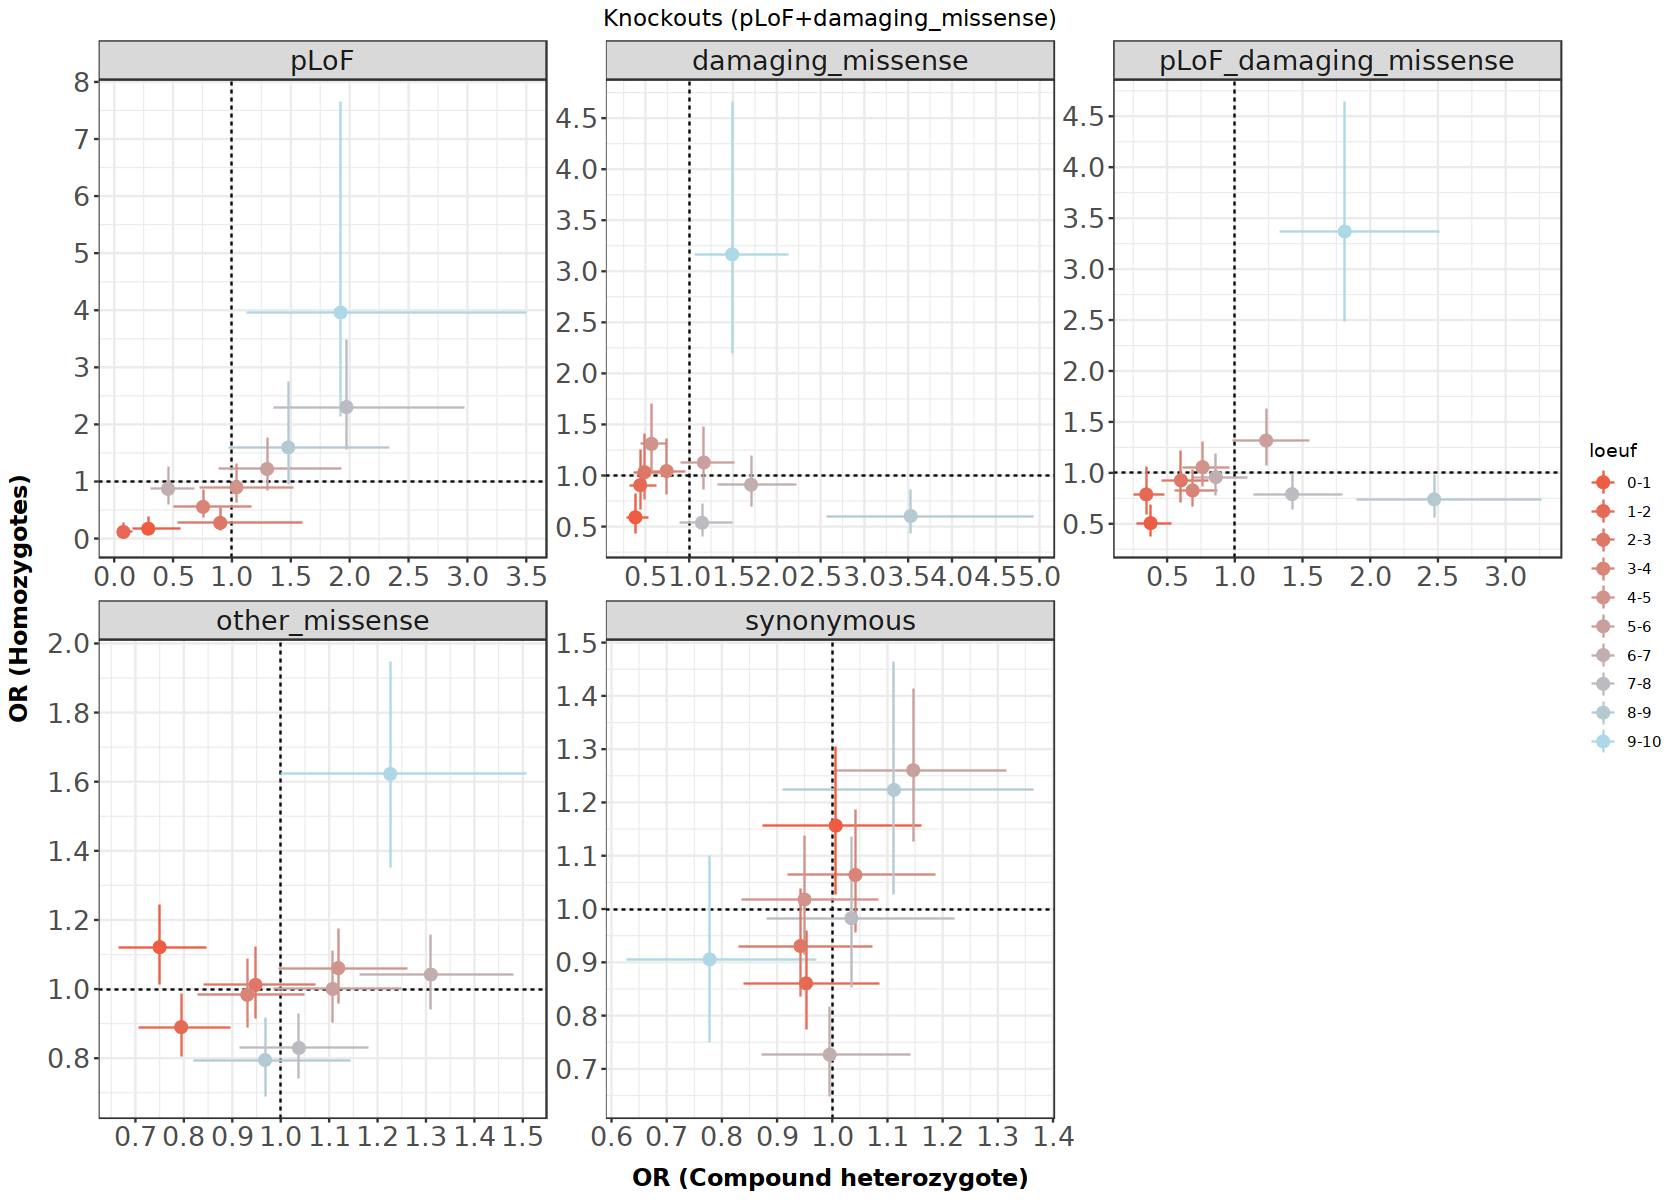

In [14]:
options(repr.plot.width=14, repr.plot.height=10)
ggplot(d, aes(
             y=hom_ci_est, #ymin=hom_ci_lower, ymax=hom_ci_upper, 
             x=chet_ci_est,# xmin=chet_ci_lower, xmax=chet_ci_upper, 
             color=loeuf
            )
      ) +
    geom_hline(yintercept = 1, linetype = 'dashed') +
    geom_vline(xintercept = 1, linetype = 'dashed') +
    scale_x_continuous(breaks=scales::pretty_breaks(n=9)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=9)) +
    xlab("OR (Compound heterozygote)") + 
    ylab("OR (Homozygotes)") +
    color_scale + 
    theme_bw() +
    geom_pointrange(aes(xmin=chet_ci_lower, xmax=chet_ci_upper)) +
    geom_pointrange(aes(ymin=hom_ci_lower, ymax=hom_ci_upper)) +
    #ggtitle("Knockout depletion (pLoF+damaging_missense)") +
    ggtitle("Knockouts (pLoF+damaging_missense)") +
    geom_point(size = 2) +
        theme(
        legend.position = "right",
        strip.text = element_text(size=16),
        axis.text=element_text(size=16),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        panel.background = element_blank()
    ) +
    facet_wrap(~annotation, scales = "free")

### 3.2.1 Nice plotting by LOEUF

In [15]:
#d$annotation <- factor(d$annotation, levels = annotations)

In [16]:
d1 <- d[,c("id","hom_est", "hom_error", "hom_z", "hom_p", "hom_ci_est", "hom_ci_lower", "hom_ci_upper", "annotation", "loeuf")]
d2 <- d[,c("id","chet_est", "chet_error", "chet_z", "chet_p", "chet_ci_est", "chet_ci_lower", "chet_ci_upper", "annotation", "loeuf")]
colnames(d1) <- gsub("hom_", "", colnames(d1))
colnames(d2) <- gsub("chet_", "", colnames(d2))
d1$dt_name <- "homs"
d2$dt_name <- "chets"
dout <- rbind(d1, d2)

In [17]:
categories <- c('pLoF','pLoF_damaging_missense','damaging_missense','other_missense','synonymous')
my_colors <- c("#B13F64","#DD686D","#F09D7C", "#F4D400", "#7CA98A")
names(my_colors) <- categories
fill_scale <- scale_fill_manual(name = "annotation", values = my_colors)
color_scale <- scale_color_manual(name = "annotation", values = my_colors)
levels(dout$annotation) <- categories

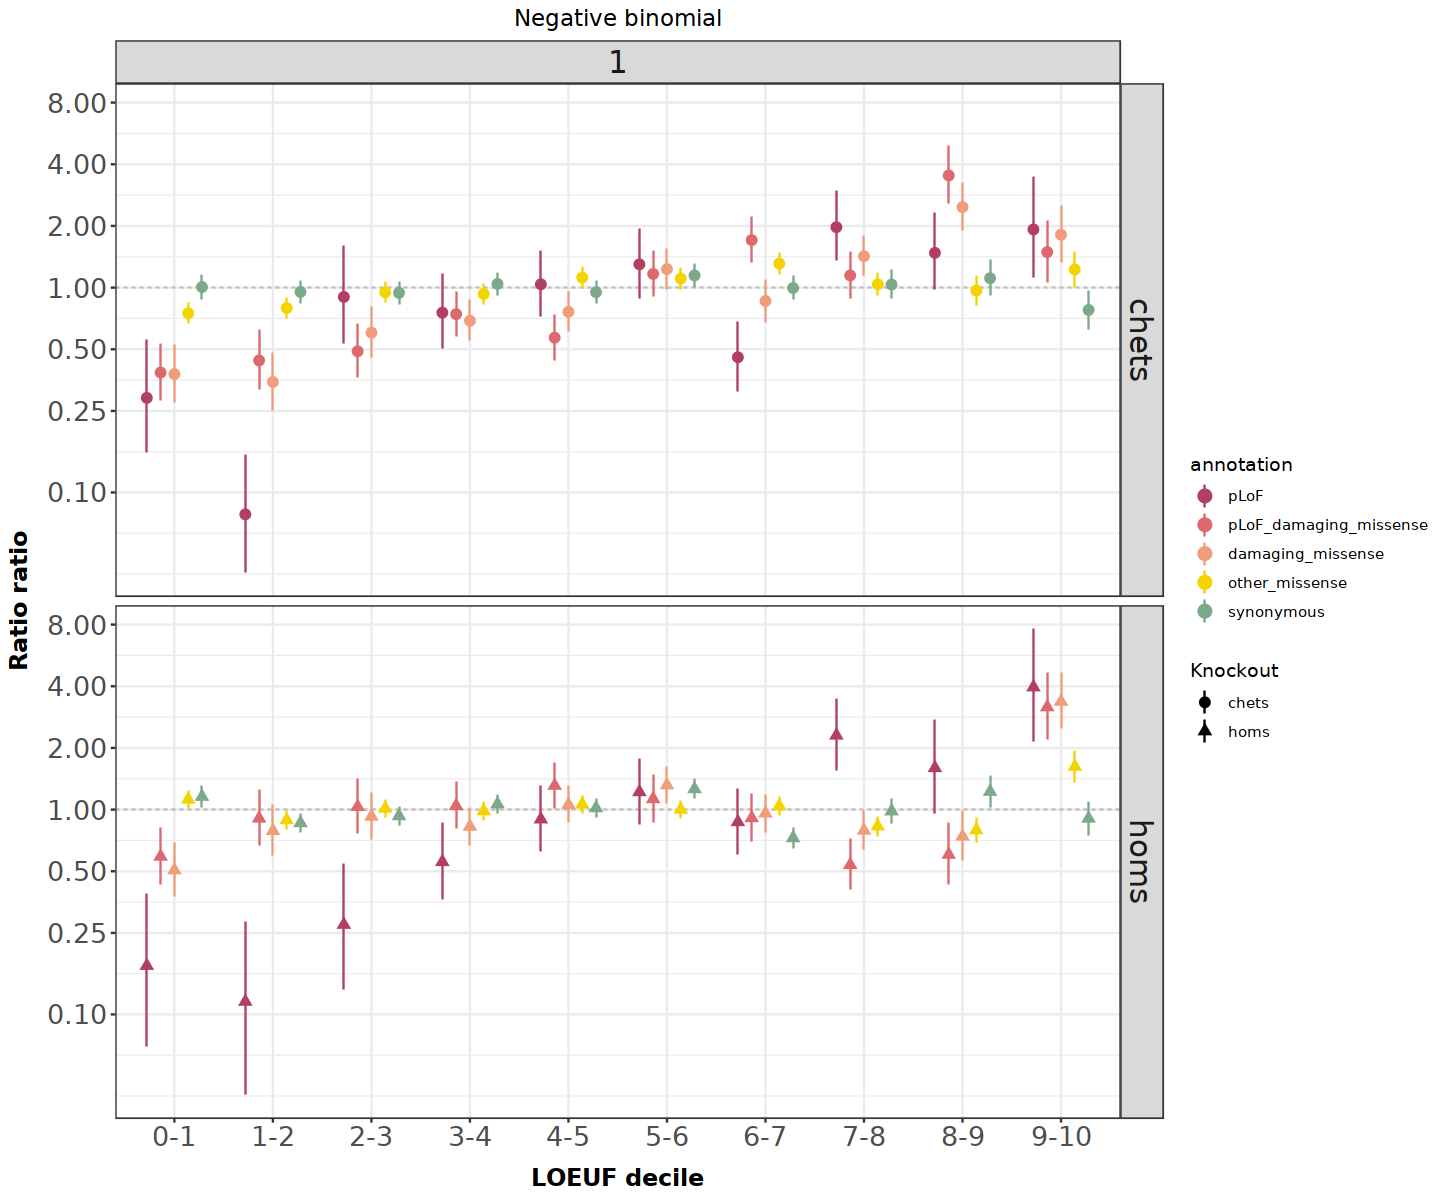

In [18]:
options(repr.plot.width=12, repr.plot.height=10)
pd <- position_dodge(0.7)
ggplot(dout, aes(
             x=loeuf,
             y=ci_est, 
             ymin=ci_lower, 
             ymax=ci_upper, 
             color=annotation,
             group=annotation,
             shape=dt_name
            )
      ) +
    geom_hline(yintercept = 1, linetype = 'dashed', color = "grey") +
    geom_pointrange(position = pd, size = 0.6) +
    scale_y_continuous(
        #breaks=scales::pretty_breaks(n=5), 
        trans="log10",
        breaks=c(0.1, 0.25, 0.5, 1, 2, 4, 8)
    ) +
    #coord_cartesian(ylim=c(0, 5)) +
    xlab("LOEUF decile") + 
    ylab("Ratio ratio") +
    color_scale + 
    theme_bw() +
    labs(shape="Knockout", color = "Annotation") +
    ggtitle("Negative binomial") +
        theme(
        legend.position = "right",
        strip.text = element_text(size=18),
        axis.text=element_text(size=16),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        #panel.background = element_blank(),
        #panel.grid.major = element_blank(), 
        #panel.grid.minor = element_blank()
    ) +
    facet_grid(dt_name~1)


In [ ]:
options(repr.plot.width=16, repr.plot.height=6)
ggplot(d, aes(
             y=hom_ci_est, #ymin=hom_ci_lower, ymax=hom_ci_upper, 
             x=chet_ci_est,# xmin=chet_ci_lower, xmax=chet_ci_upper, 
             color=loeuf
            )
      ) +
    geom_hline(yintercept = 1, linetype = 'dashed') +
    geom_vline(xintercept = 1, linetype = 'dashed') +
    scale_x_continuous(breaks=scales::pretty_breaks(n=9)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=9)) +
    xlab("OR (Compound heterozygote)") + 
    ylab("OR (Homozygotes)") +
    color_scale + 
    theme_bw() +
    geom_pointrange(aes(xmin=chet_ci_lower, xmax=chet_ci_upper)) +
    geom_pointrange(aes(ymin=hom_ci_lower, ymax=hom_ci_upper)) +
    #ggtitle("Knockout depletion (pLoF+damaging_missense)") +
    ggtitle("Knockouts (pLoF+damaging_missense)") +
    geom_point(size = 2) +
        theme(
        legend.position = "right",
        strip.text = element_text(size=16),
        axis.text=element_text(size=16),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        panel.background = element_blank()
    ) +
    facet_grid(""~annotation)

### 3.2 Modelling two-het cis by LOEUF

In [176]:
dt_subset <- dt[dt$annotation == "pLoF_damaging_missense",]
lst_data <- list(
    homzygotes = dt_subset[(dt_subset$is_hom | dt_subset$is_cis),],
    chets = dt_subset[(dt_subset$is_chet | dt_subset$is_cis),]
)

In [177]:
lst <- lapply(names(lst_data), function(dt_name) {
    
    print(dt_name)
    full <- lst_data[[dt_name]]
    aggr_ko <- aggregate(is_cis ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=sum)
    aggr_full <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=length)
    aggr <- merge(aggr_ko, aggr_full, by = c("ensembl_gene_id","ensembl_transcript_id"))
    colnames(aggr) <- c("ensembl_gene_id","ensembl_transcript_id", "n","total")
    mrg <- merge(aggr, geneset, by = c("ensembl_gene_id", "ensembl_transcript_id"), all.x = TRUE)
    
    lst <- lapply(categories, function(category){
        dt_fit <- mrg
        na_rows <- rowSums(is.na(dt_fit[,c('n','length','length2')]))
        dt_fit <- dt_fit[!na_rows,]
        
        dt_fit$x <- FALSE
        dt_fit$x[dt_fit$oe_lof_upper_bin == category] <- TRUE
        
        model <- as.formula("n~x+length+length2")
        x <- glm.nb(model, data = dt_fit, init.theta = 1.041, link = "log") #
        fit <- data.frame(coef(summary(x)))
        colnames(fit) <- c("est", "error", "z", "p")

        conf <- suppressMessages(exp(cbind(coef(x), confint(x))))
        fit$ci_est <- conf[,1]
        fit$ci_lower <- conf[,2]
        fit$ci_upper <- conf[,3]
        
        #model <- as.formula("n~x+length+length2|1")
        #x <- zeroinfl(model, data = dt_fit)
        #fit <- data.frame(summary(x)[[1]]$count)
        #colnames(fit) <- c("est", "error", "z", "p")

        #conf <- suppressMessages(exp(cbind(fit[,1], confint(x)[1:4,])))
        #fit$ci_est <- conf[,1]
        #fit$ci_lower <- conf[,2]
        #fit$ci_upper <- conf[,3]
        
        fit$keep <- as.logical(c(0, 1, 0, 0))
        fit$id <- category
        rownames(fit) <- NULL
        return(fit)
    })
    
    out <- do.call(rbind, lst)
    out$annotation <- dt_name
    return(out)
})

[1] "homzygotes"


Warning message:
"glm.fit: algorithm did not converge"
Warning message:
"glm.fit: algorithm did not converge"


[1] "chets"


Warning message:
"glm.fit: algorithm did not converge"


In [179]:
d1 <- lst[[1]]
d1 <- d1[d1$keep == 1, ]
d2 <- lst[[2]]
d2 <- d2[d2$keep == 1, ]
colnames(d1)[1:8] <- paste0("hom_",colnames(d1)[1:8])
colnames(d2)[1:8] <- paste0("chet_",colnames(d2)[1:8])
d <- merge(d1, d2, by = "id")

In [180]:
#d$id <- factor(as.character(d$id), levels <- as.character(0:9))
ids <- sort(unique(d$id))
d$loeuf <- factor(unlist(lapply(ids, function(id) paste0(id,'-',id+1))))


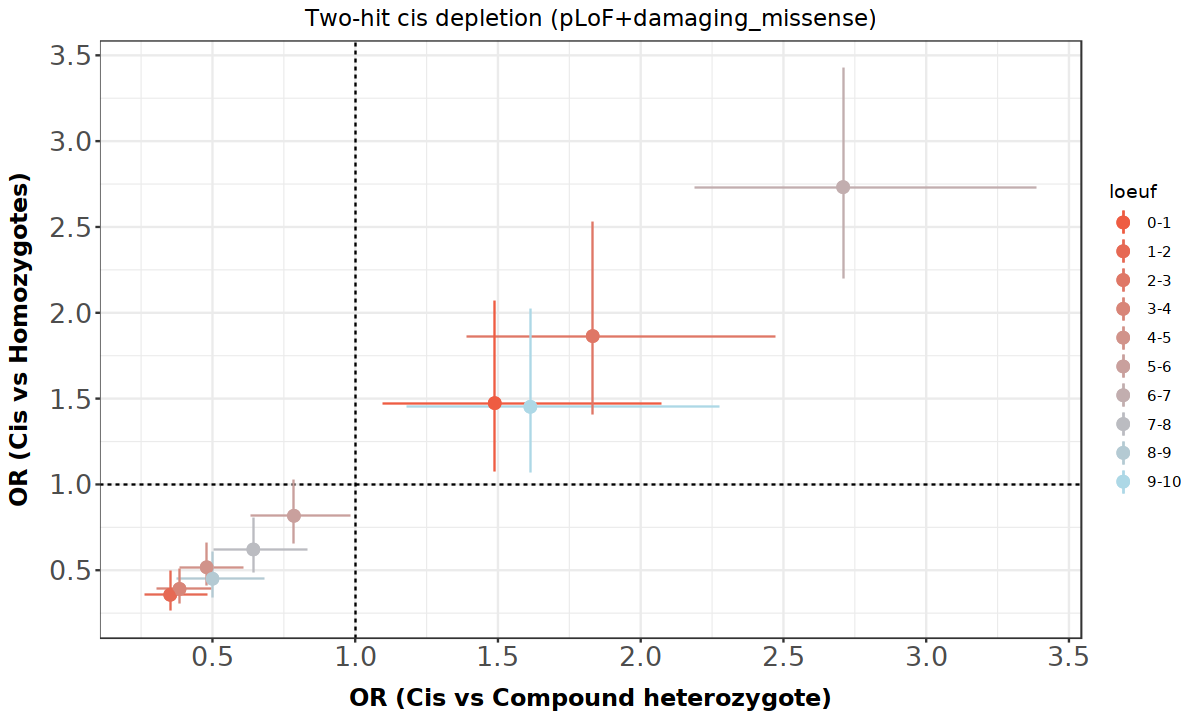

In [182]:
options(repr.plot.width=10, repr.plot.height=6)
ggplot(d, aes(
             y=hom_ci_est, #ymin=hom_ci_lower, ymax=hom_ci_upper, 
             x=chet_ci_est,# xmin=chet_ci_lower, xmax=chet_ci_upper, 
             color=loeuf
            )
      ) +
    geom_hline(yintercept = 1, linetype = 'dashed') +
    geom_vline(xintercept = 1, linetype = 'dashed') +
    scale_x_continuous(breaks=scales::pretty_breaks(n=9)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=9)) +
    xlab("OR (Cis vs Compound heterozygote)") + 
    ylab("OR (Cis vs Homozygotes)") +
    color_scale + 
    theme_bw() +
    geom_pointrange(aes(xmin=chet_ci_lower, xmax=chet_ci_upper)) +
    geom_pointrange(aes(ymin=hom_ci_lower, ymax=hom_ci_upper)) +
    #ggtitle("Knockout depletion (pLoF+damaging_missense)") +
    ggtitle("Two-hit cis depletion (pLoF+damaging_missense)") +
    geom_point(size = 2) +
        theme(
        legend.position = "right",
        strip.text = element_text(size=16),
        axis.text=element_text(size=16),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        panel.background = element_blank()
    ) 

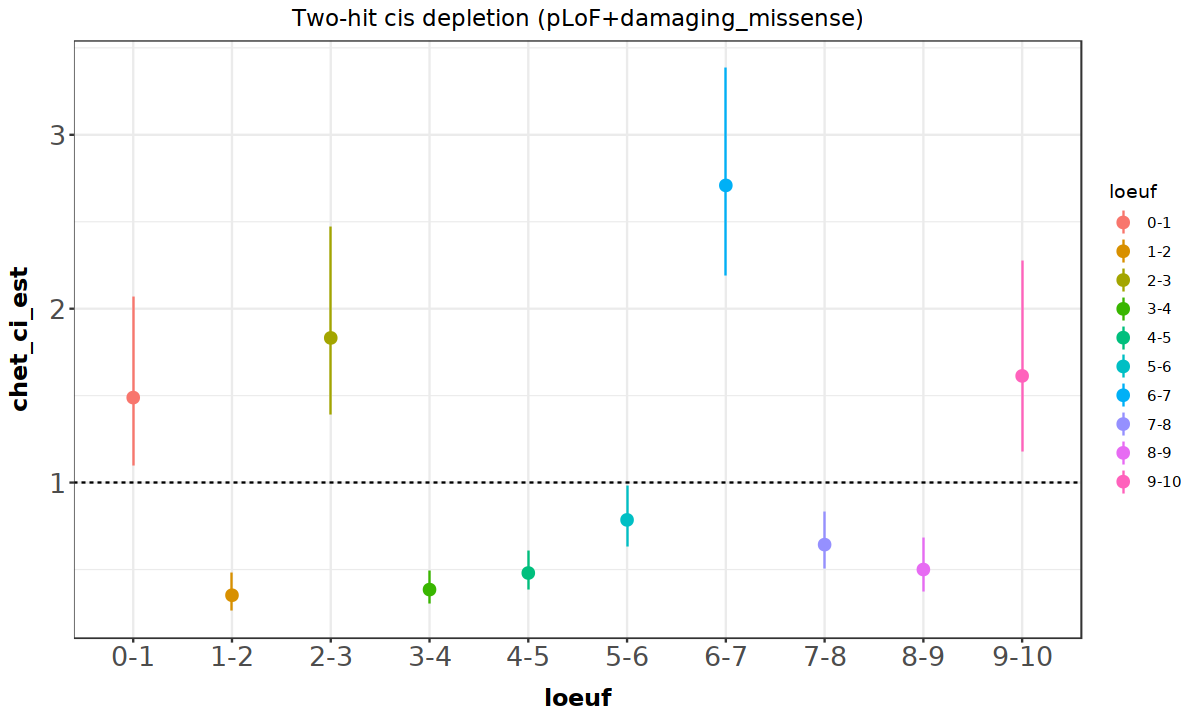

In [324]:
options(repr.plot.width=10, repr.plot.height=6)
ggplot(d, aes(
             y=chet_ci_est,
             x=loeuf,
             color=loeuf
            )
      ) +
    
    geom_hline(yintercept = 1, linetype = 'dashed') +
    #geom_vline(xintercept = 1, linetype = 'dashed') +
    #scale_x_continuous(breaks=scales::pretty_breaks(n=9)) +
    #scale_y_continuous(breaks=scales::pretty_breaks(n=9)) +
    #xlab("OR (Compound heterozygote)") + 
    #ylab("OR (Homozygotes)") +
    fill_scale + 
    theme_bw() +
    geom_pointrange(aes(ymin=chet_ci_lower, ymax=chet_ci_upper)) +
    #geom_pointrange(aes(ymin=hom_ci_lower, ymax=hom_ci_upper)) +
    #ggtitle("Knockout depletion (pLoF+damaging_missense)") +
    ggtitle("Two-hit cis depletion (pLoF+damaging_missense)") +
        theme(
        legend.position = "right",
        strip.text = element_text(size=16),
        axis.text=element_text(size=16),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        panel.background = element_blank()
    )

## 3.3 Logistic regression for phenotype enrichment

In [5]:
# retrive them
pLoF <- read_ukb_wes_kos("pLoF")
damaging_missense <- read_ukb_wes_kos("damaging_missense")
pLoF_damaging_missense <- read_ukb_wes_kos("pLoF_damaging_missense")

# annotate
pLoF$annotation <- "pLoF"
damaging_missense$annotation <- "damaging_missense"
pLoF_damaging_missense$annotation <- "pLoF_damaging_missense"

In [6]:
# keep only relevant columns
cols_to_keep <- c("gene_id","s","knockout","annotation", "pKO", "chromosome", "transcript_id")
dt <- setDT(rbind(pLoF, damaging_missense, pLoF_damaging_missense))
dt <- dt[!(dt$knockout %in% "Heterozygote"), ]
dt <- dt[,colnames(dt) %in% cols_to_keep, with = FALSE]

# format
dt$is_chet <- dt$knockout %in% "Compound heterozygote"
dt$is_cis <- dt$knockout %in% "Compound heterozygote (cis)"
dt$is_hom <- dt$knockout %in% "Homozygote"
dt$is_ko <- dt$is_hom | dt$is_chet
dt$knockout <- NULL

# exclude common knockoiuts
counts <- data.table(table(dt$is_ko, dt$gene_id))
counts <- counts[counts$V1 == TRUE,]
counts <- counts[rev(order(counts$N))]
gene_id_exclude <- counts$V2[counts$N > 10000]
dt <- dt[!(dt$gene_id %in% gene_id_exclude),]

# rename for easier downstream
colnames(dt)[colnames(dt) == "gene_id"] <- "ensembl_gene_id"
colnames(dt)[colnames(dt) == "transcript_id"] <- "ensembl_transcript_id"

In [46]:
# get gnomad geneset and create mapping
gnomad_genesets <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/gnomad/karczewski2020/supplementary_dataset_11_full_constraint_metrics.tsv")
gnomad_genesets <- gnomad_genesets[gnomad_genesets$canonical,]
cols_to_keep <- c('gene','gene_id','transcript','oe_lof_upper_bin','oe_lof_upper', "pLI")
gnomad_genesets <- gnomad_genesets[,colnames(gnomad_genesets) %in% cols_to_keep, with = FALSE]
colnames(gnomad_genesets)[colnames(gnomad_genesets) == "gene_id"] <- "ensembl_gene_id"
colnames(gnomad_genesets)[colnames(gnomad_genesets) == "gene"] <- "hgnc_symbol"
colnames(gnomad_genesets)[colnames(gnomad_genesets) == "transcript"] <- "ensembl_transcript_id"
colnames(gnomad_genesets)[colnames(gnomad_genesets) == "oe_lof_upper"] <- "loeuf"
gnomad_genesets$pLI_cutoff <- gnomad_genesets$pLI >= 0.9

In [99]:
# load phenotypes
icd <- fread("/well/lindgren-ukbb/projects/ukbb-11867/samvida/general_resources/UKB_codelists/chronological-map-phenotypes/annot_dictionary_with_unix_codes.txt")
icd$spiro_unix_code <- paste("spiro_", icd$unix_code, sep = "")
phenos <- fread("data/phenotypes/dec22_phenotypes_binary_200k.tsv.gz")


In [134]:
categories <- unique(icd$ICD_chapter)
dt_subset <- dt[dt$annotation == "pLoF_damaging_missense",]
lst_data <- list(
    homzygotes = dt_subset[(dt_subset$is_hom | dt_subset$is_cis),],
    chets = dt_subset[(dt_subset$is_chet | dt_subset$is_cis),]
)

In [94]:
full <- dt_subset
aggr <- merge(full, gnomad_genesets, by = c("ensembl_gene_id","ensembl_transcript_id"))
aggr <- aggregate(pLI_cutoff ~ s, data = aggr, FUN=sum)
colnames(aggr) <- c("eid","ko")
aggr$ko[aggr$ko > 1] <- 1

In [95]:
unrelated <- fread("data/post_hoc/unrelated/ukb_wes_ko_samples.txt.gz")$s
dt_fit <- merge(phenos, aggr, by = 'eid', all.x = TRUE)
dt_fit <- dt_fit[dt_fit$eid %in% unrelated,]
dt_fit$ko[dt_fit$ko > 1] <- 1
dt_fit <- dt_fit[!is.na(dt_fit$ko),]

In [96]:
dt_fit$sex <- factor(dt_fit$sex)
dt_fit$ukbb.centre <- factor(dt_fit$ukbb.centre)

In [126]:
lst <- lapply(categories, function(category){
        
    
        if (category %in% colnames(dt_fit)) {
            dt_fit$ph <- dt_fit[[category]]
            model <- as.formula("ph ~ ko + age + age2 + sex + ukbb.centre")
            x <- glm(model, data = dt_fit, family = 'binomial') #
            fit <- data.frame(coef(summary(x)))
            colnames(fit) <- c("est", "error", "z", "p")
            fit$keep <- as.logical(c(0, 1, rep(0, 24)))
            fit$id <- category
            rownames(fit) <- NULL
            return(fit)  
        }
    })

Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"


In [127]:
out <- do.call(rbind, lst)
out <- out[out$keep,]

In [133]:
out[order(out$p),]

,est,error,z,p,keep,id
,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>
5124,0.36416971,0.12077303,3.015323,0.002567057,TRUE,spiro_primary_malignancy_malignant_melanoma
6528,0.80939888,0.29741821,2.721417,0.006500276,TRUE,spiro_spina_bifida
1900,0.17649044,0.06606132,2.671615,0.007548711,TRUE,spiro_erectile_dysfunction
5514,-0.32942405,0.13607134,-2.420966,0.015479335,TRUE,spiro_primary_malignancy_colorectal_and_anus
1640,-1.71507053,0.71393798,-2.402268,0.016293755,TRUE,spiro_dilated_cardiomyopathy
6840,-1.20772107,0.50804975,-2.377171,0.017446004,TRUE,spiro_thrombophilia
5384,0.63767143,0.28362456,2.248294,0.024557441,TRUE,spiro_primary_malignancy_stomach
5254,-0.33496477,0.15203704,-2.203179,0.027582157,TRUE,spiro_primary_malignancy_other_organs
4110,-0.79399918,0.36238773,-2.191021,0.028450264,TRUE,spiro_other_cardiomyopathy


In [131]:
log10(0.05/280)

[1] -3.748188

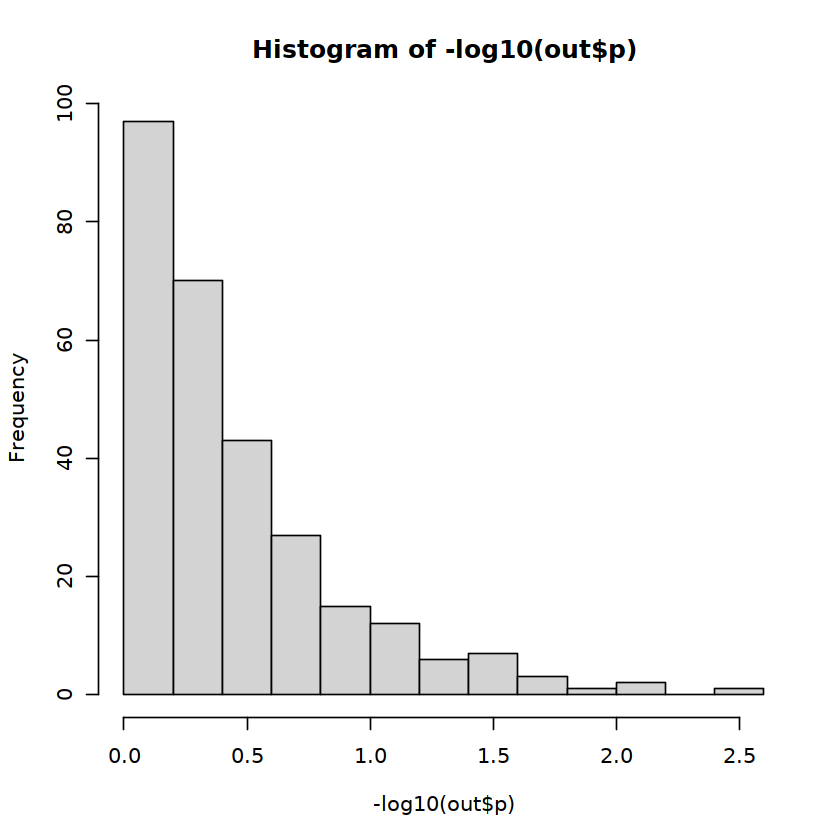

In [129]:
hist(-log10(out$p))